In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings

In [2]:
df = pd.read_csv("C:/Users/kerem/Desktop/Akıllı Trafik/Veri hazırlık/trafik_hava.csv")

warnings.filterwarnings('ignore')

df = df.drop(columns=['Sicaklik', 'Yagis', "Ruzgar_Hizi", "Nem", "Bulutluluk"], errors='ignore')
df.to_csv("proje.csv", index=False, encoding="utf-8-sig")

veri = df.copy()

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda  x: '%.3f' % x)
pd.set_option('display.width', 1000)

Yoğunluk Endeksi Oluştur

In [4]:
veri['DENSITY'] = veri['NUMBER_OF_VEHICLES'] / veri['AVERAGE_SPEED']

print(veri.head())

print("\nYoğunluk Sütununun İstatistiksel Özeti:")
print(veri['DENSITY'].describe())

Yeni 'Yoğunluk_Endeksi' sütunu ile DataFrame'in ilk 5 satırı:
  GEOHASH_SHORT        DATE   TIME_PERIOD  MINIMUM_SPEED  MAXIMUM_SPEED  AVERAGE_SPEED  NUMBER_OF_VEHICLES rainfall_condition  DENSITY
0         sx7ch  2024-01-01       Daytime              1            161             65                 722           Yağışsız   11.108
1         sx7ch  2024-01-01  Evening_Peak              2            137             59                 789           Yağışsız   13.373
2         sx7ch  2024-01-01  Late_Evening              1            149             71                 531           Yağışsız    7.479
3         sx7ch  2024-01-01  Morning_Peak              2            135             69                 194           Yağışsız    2.812
4         sx7ch  2024-01-01         Night              5            133             67                 217           Yağışsız    3.239

'Yoğunluk_Endeksi' Sütununun İstatistiksel Özeti:
count   271006.000
mean       141.040
std        255.694
min          0.006
2

Zaman Özellikleri (Time Features) Oluşturma

In [5]:
veri['DATE'] = pd.to_datetime(veri['DATE'])

veri['haftanin_gunu'] = veri['DATE'].dt.dayofweek  # 0=Pazartesi, 6=Pazar
veri['ay'] = veri['DATE'].dt.month
veri['gun_no'] = veri['DATE'].dt.dayofyear
veri['hafta_sonu_mu'] = veri['DATE'].dt.dayofweek.isin([5, 6]).astype(int) # 1=Haftasonu

In [6]:
time_period_map = {
    'night': 0,
    'morning_peak': 1,
    'daytime': 2,
    'evening_peak': 3,
    'late_evening': 4
}

veri['TIME_PERIOD_STR'] = (
    veri['TIME_PERIOD']
        .astype(str)
        .str.strip()
        .str.replace(" ", "_")
        .str.lower()
)
veri['TIME_PERIOD_NUM'] = veri['TIME_PERIOD_STR'].map(time_period_map).fillna(-1).astype(int)

Lag ve rolling (kritik)

In [7]:
def create_lags_safe(veri, col='DENSITY', lags=[1,5,10,35], rolls=[3,5,10,35], group_col='GEOHASH_SHORT'):
    veri = veri.sort_values(["GEOHASH_SHORT", "DATE", "TIME_PERIOD_NUM"]).copy()
    # lags
    for l in lags:
        veri[f'{col}_lag_{l}'] = veri.groupby(group_col)[col].shift(l)
    # group-wise rolling (shift 1 önce yapıp sonra her grup için rolling)
    for r in rolls:
        veri[f'{col}_roll_mean_{r}'] = (
            veri.groupby(group_col)[col].shift(1)
                .groupby(veri[group_col])
                .rolling(r, min_periods=1).mean()
                .reset_index(level=0, drop=True)
        )

        veri[f'{col}_roll_std_{r}'] = (
            veri.groupby(group_col)[col].shift(1)
                .groupby(veri[group_col])
                .rolling(r, min_periods=1).std()
                .reset_index(level=0, drop=True)
        )
    return veri

veri = create_lags_safe(veri)

Mekânsal özellikler

In [8]:
import pygeohash as pgh
veri['lat'] = veri['GEOHASH_SHORT'].apply(lambda x: pgh.decode(x)[0])
veri['lon'] = veri['GEOHASH_SHORT'].apply(lambda x: pgh.decode(x)[1])

In [9]:
# Genel Resmi İnceledim
def check_df(dataframe):
    print("############## Shape ##############")
    print(dataframe.shape)
    print("############## Types ##############")
    print(dataframe.dtypes)
    print("############## Head ##############")
    print(dataframe.head(3))
    print("############## Tail ##############")
    print(dataframe.tail(3))
    print("############## NA ##############")
    print(dataframe.isnull().sum())
    print("############## Quantiles ##############")
    numeric_cols = dataframe.select_dtypes(include=["int64", "float64"]).columns
    print(dataframe[numeric_cols].quantile([0, 0.05, 0.5, 0.95, 0.99, 1]).T)
check_df(veri)

############## Shape ##############
(271006, 29)
############## Types ##############
GEOHASH_SHORT                   object
DATE                    datetime64[ns]
TIME_PERIOD                     object
MINIMUM_SPEED                    int64
MAXIMUM_SPEED                    int64
AVERAGE_SPEED                    int64
NUMBER_OF_VEHICLES               int64
rainfall_condition              object
DENSITY                        float64
haftanin_gunu                    int32
ay                               int32
gun_no                           int32
hafta_sonu_mu                    int64
TIME_PERIOD_STR                 object
TIME_PERIOD_NUM                  int64
DENSITY_lag_1                  float64
DENSITY_lag_5                  float64
DENSITY_lag_10                 float64
DENSITY_lag_35                 float64
DENSITY_roll_mean_3            float64
DENSITY_roll_std_3             float64
DENSITY_roll_mean_5            float64
DENSITY_roll_std_5             float64
DENSITY_roll_mean_

Nümerik ve Kategorik Değişkenlerin Yakalanması

In [10]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    grab_col_names for given dataframe

    :param dataframe:
    :param cat_th:
    :param car_th:
    :return:
    """

    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]

    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    # cat_cols + num_cols + cat_but_car = değişken sayısı.
    # num_but_cat cat_cols'un içerisinde zaten.
    # dolayısıyla tüm şu 3 liste ile tüm değişkenler seçilmiş olacaktır: cat_cols + num_cols + cat_but_car
    # num_but_cat sadece raporlama için verilmiştir.

    return cat_cols, cat_but_car, num_cols

cat_cols, cat_but_car, num_cols = grab_col_names(veri)

Observations: 271006
Variables: 29
cat_cols: 6
num_cols: 22
cat_but_car: 1
num_but_cat: 3


Kategorik Değişken Analizi

              TIME_PERIOD  Ratio
TIME_PERIOD                     
Night               55618 20.523
Morning_Peak        55099 20.331
Daytime             54205 20.001
Evening_Peak        53731 19.826
Late_Evening        52353 19.318


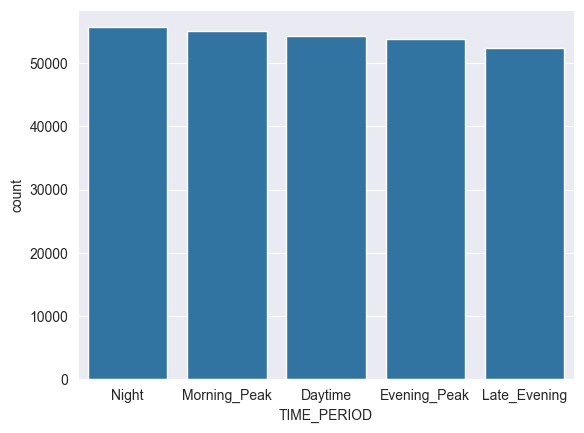

                    rainfall_condition  Ratio
rainfall_condition                           
Yağışsız                        168172 62.055
Hafif Yağmur                     97862 36.111
Sağanak                           3978  1.468
Yağışlı                            994  0.367


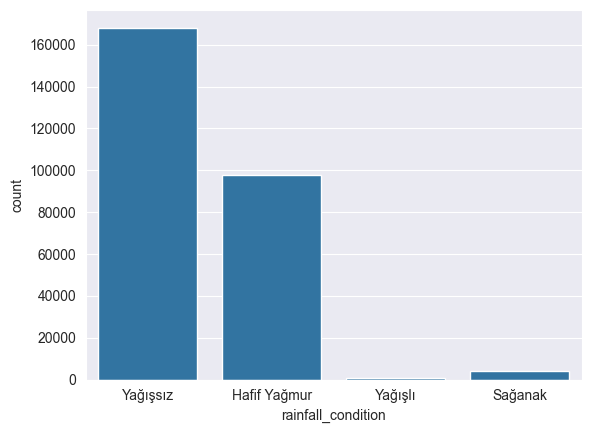

                 TIME_PERIOD_STR  Ratio
TIME_PERIOD_STR                        
night                      55618 20.523
morning_peak               55099 20.331
daytime                    54205 20.001
evening_peak               53731 19.826
late_evening               52353 19.318


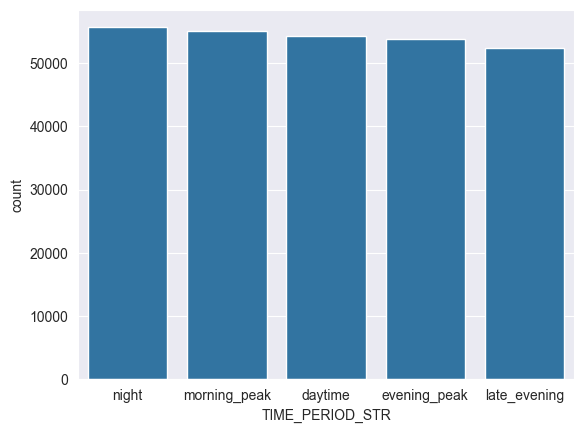

               haftanin_gunu  Ratio
haftanin_gunu                      
6                      40561 14.967
0                      40233 14.846
3                      40158 14.818
4                      38170 14.085
2                      37579 13.866
5                      37388 13.796
1                      36917 13.622


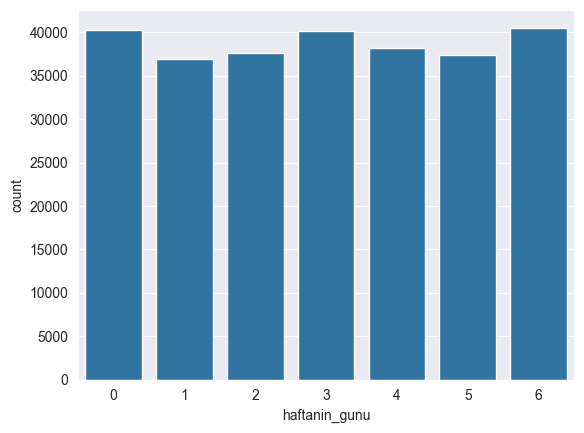

               hafta_sonu_mu  Ratio
hafta_sonu_mu                      
0                     193057 71.237
1                      77949 28.763


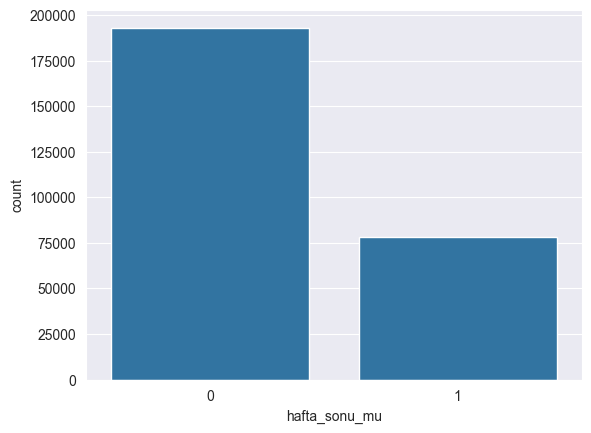

                 TIME_PERIOD_NUM  Ratio
TIME_PERIOD_NUM                        
0                          55618 20.523
1                          55099 20.331
2                          54205 20.001
3                          53731 19.826
4                          52353 19.318


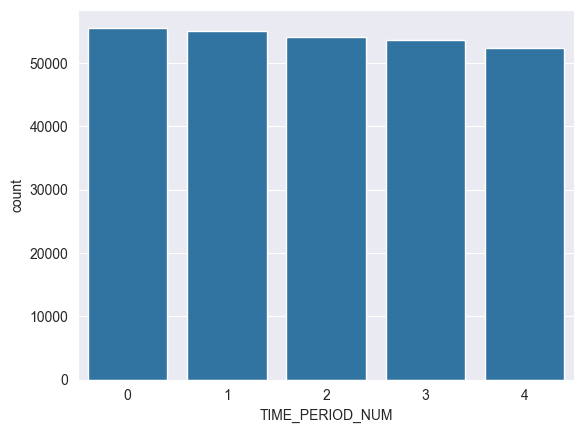

In [11]:
def cat_summary(dataframe, col_name, plot=True):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))

    if plot:
        sns.countplot(x=dataframe[col_name],data=dataframe)
        plt.show(block=True)

for col in cat_cols:
    cat_summary(veri, col)

Sayısal Değişken Analizi

count                           271006
mean     2024-06-15 00:46:52.560607232
min                2024-01-01 00:00:00
5%                 2024-01-28 00:00:00
10%                2024-02-12 00:00:00
20%                2024-03-10 00:00:00
30%                2024-04-07 00:00:00
40%                2024-05-05 00:00:00
50%                2024-06-03 00:00:00
60%                2024-07-03 00:00:00
70%                2024-08-13 00:00:00
80%                2024-10-02 00:00:00
90%                2024-11-11 00:00:00
95%                2024-12-06 00:00:00
99%                2024-12-20 00:00:00
max                2024-12-24 00:00:00
Name: DATE, dtype: object


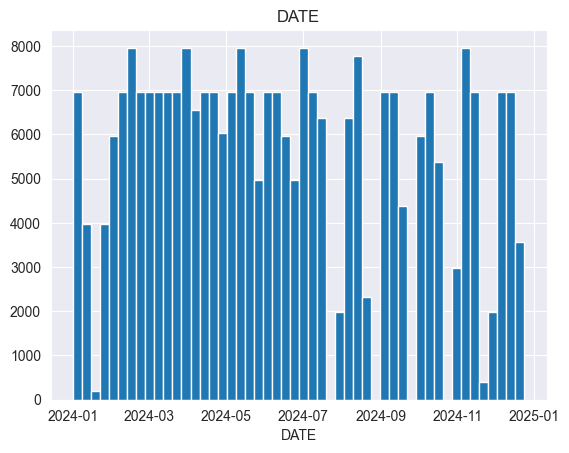

###########################
count   271006.000
mean         8.168
std         12.638
min          0.000
5%           1.000
10%          1.000
20%          1.000
30%          1.000
40%          2.000
50%          2.000
60%          4.000
70%          6.000
80%         11.000
90%         26.000
95%         40.000
99%         55.000
max        163.000
Name: MINIMUM_SPEED, dtype: float64


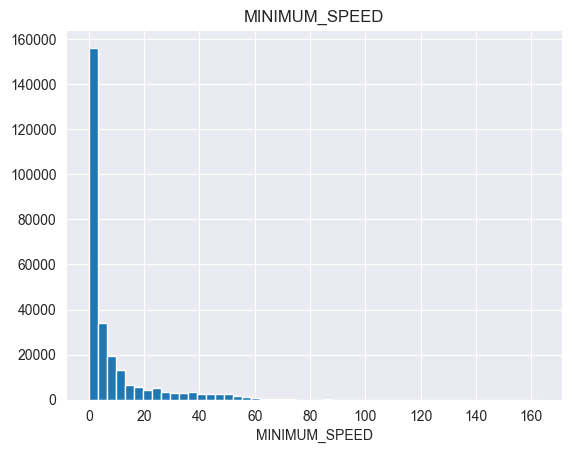

###########################
count   271006.000
mean       152.649
std         32.221
min          3.000
5%          98.000
10%        112.000
20%        126.000
30%        136.000
40%        145.000
50%        154.000
60%        163.000
70%        172.000
80%        181.000
90%        192.000
95%        201.000
99%        218.000
max        251.000
Name: MAXIMUM_SPEED, dtype: float64


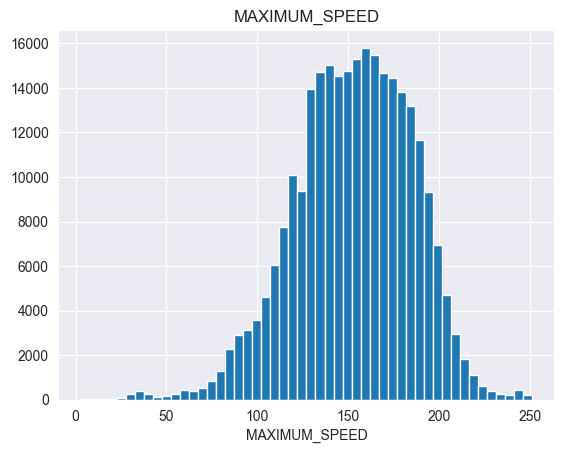

###########################
count   271006.000
mean        64.799
std         21.743
min          2.000
5%          29.000
10%         34.000
20%         42.000
30%         50.000
40%         59.000
50%         68.000
60%         75.000
70%         80.000
80%         86.000
90%         92.000
95%         96.000
99%        104.000
max        163.000
Name: AVERAGE_SPEED, dtype: float64


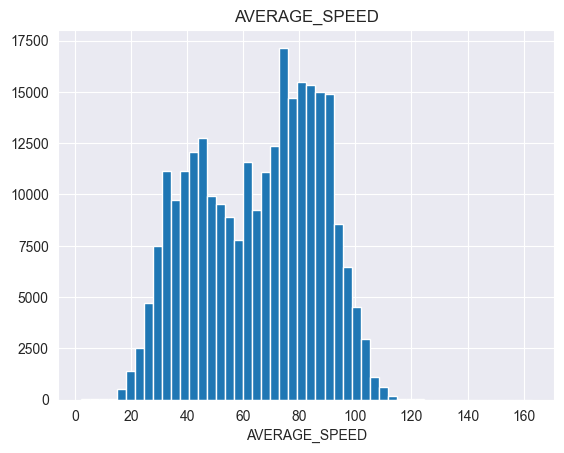

###########################
count   271006.000
mean      6185.864
std       8627.913
min          1.000
5%         113.000
10%        241.000
20%        587.000
30%       1038.000
40%       1680.000
50%       2649.000
60%       4200.000
70%       6612.000
80%      10112.000
90%      16921.500
95%      24003.750
99%      41703.800
max     110140.000
Name: NUMBER_OF_VEHICLES, dtype: float64


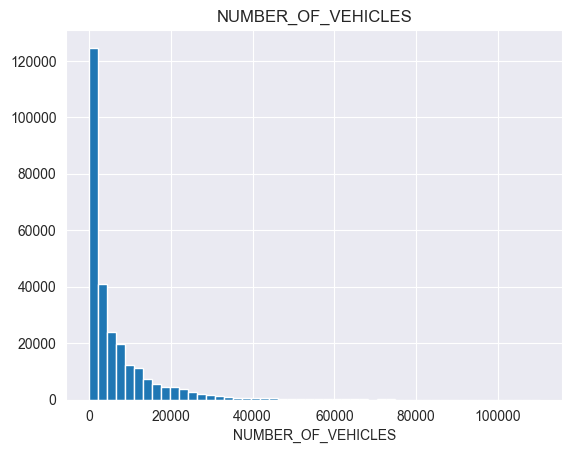

###########################
count   271006.000
mean       141.040
std        255.694
min          0.006
5%           1.671
10%          3.644
20%          8.478
30%         14.493
40%         23.340
50%         37.583
60%         61.775
70%        107.688
80%        196.247
90%        405.312
95%        671.833
99%       1289.089
max       3187.308
Name: DENSITY, dtype: float64


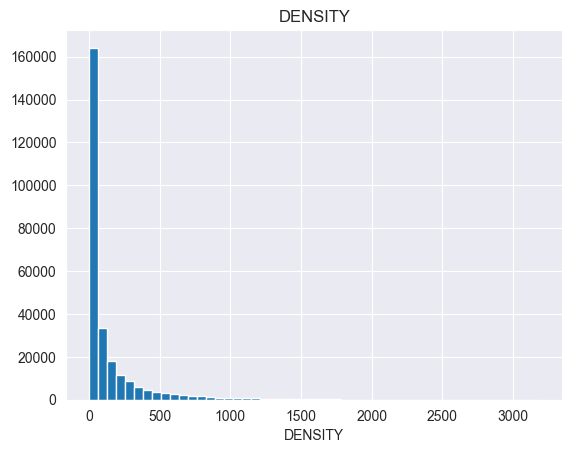

###########################
count   271006.000
mean         6.062
std          3.326
min          1.000
5%           1.000
10%          2.000
20%          3.000
30%          4.000
40%          5.000
50%          6.000
60%          7.000
70%          8.000
80%         10.000
90%         11.000
95%         12.000
99%         12.000
max         12.000
Name: ay, dtype: float64


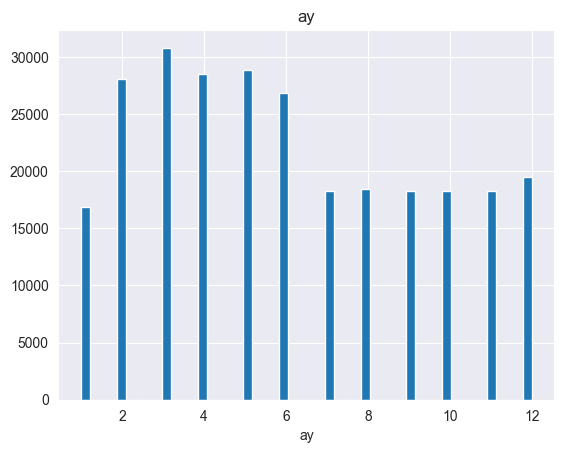

###########################
count   271006.000
mean       167.033
std         99.487
min          1.000
5%          28.000
10%         43.000
20%         70.000
30%         98.000
40%        126.000
50%        155.000
60%        185.000
70%        226.000
80%        276.000
90%        316.000
95%        341.000
99%        355.000
max        359.000
Name: gun_no, dtype: float64


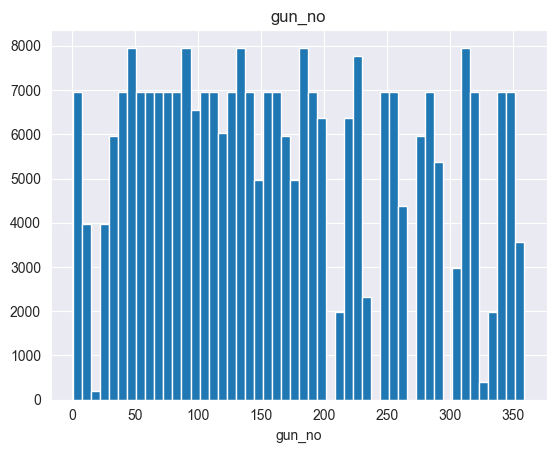

###########################
count   270807.000
mean       141.106
std        255.768
min          0.006
5%           1.671
10%          3.647
20%          8.486
30%         14.500
40%         23.354
50%         37.603
60%         61.812
70%        107.750
80%        196.348
90%        405.681
95%        672.400
99%       1289.333
max       3187.308
Name: DENSITY_lag_1, dtype: float64


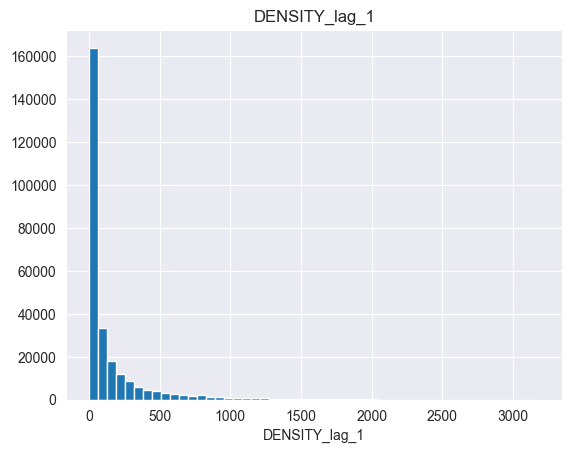

###########################
count   270011.000
mean       141.121
std        255.825
min          0.006
5%           1.672
10%          3.647
20%          8.486
30%         14.500
40%         23.362
50%         37.608
60%         61.817
70%        107.733
80%        196.353
90%        405.647
95%        672.391
99%       1289.690
max       3187.308
Name: DENSITY_lag_5, dtype: float64


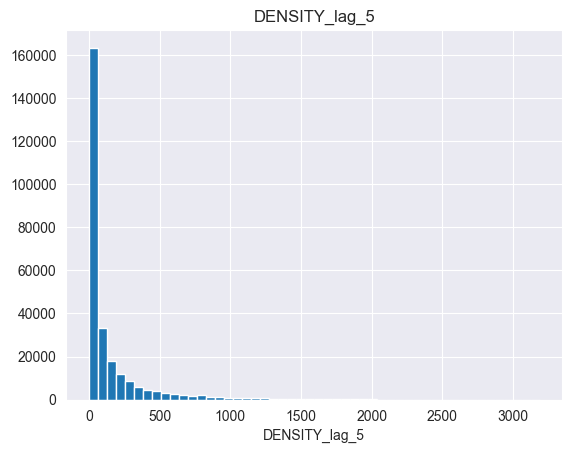

###########################
count   269016.000
mean       141.386
std        256.041
min          0.006
5%           1.685
10%          3.671
20%          8.525
30%         14.549
40%         23.440
50%         37.732
60%         62.011
70%        108.094
80%        196.958
90%        406.625
95%        673.079
99%       1289.905
max       3187.308
Name: DENSITY_lag_10, dtype: float64


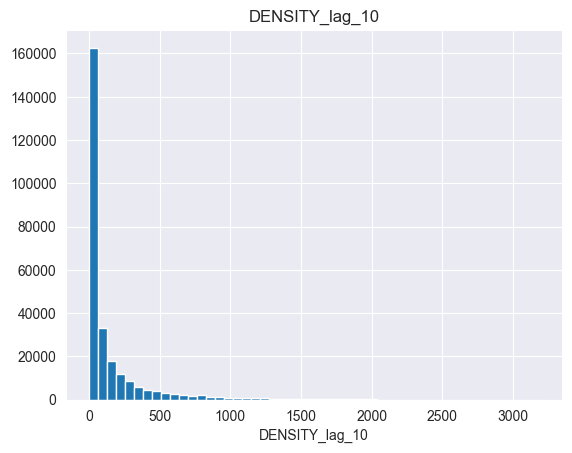

###########################
count   264041.000
mean       142.116
std        257.130
min          0.006
5%           1.701
10%          3.707
20%          8.598
30%         14.674
40%         23.612
50%         38.000
60%         62.354
70%        108.661
80%        197.961
90%        408.906
95%        677.108
99%       1294.507
max       3187.308
Name: DENSITY_lag_35, dtype: float64


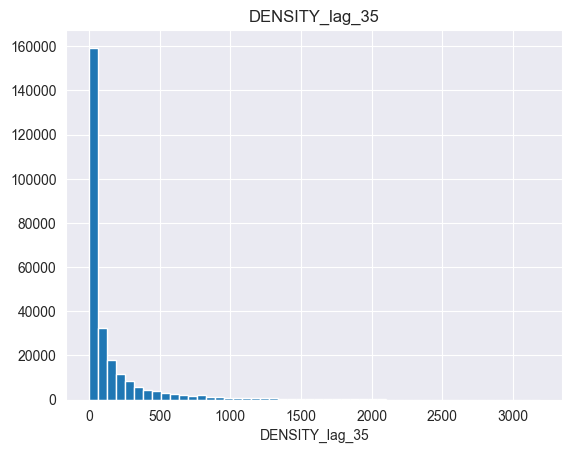

###########################
count   270807.000
mean       141.028
std        229.804
min          0.013
5%           2.177
10%          4.696
20%          9.556
30%         16.056
40%         24.941
50%         38.833
60%         65.382
70%        120.416
80%        223.918
90%        432.531
95%        633.836
99%       1104.266
max       2596.966
Name: DENSITY_roll_mean_3, dtype: float64


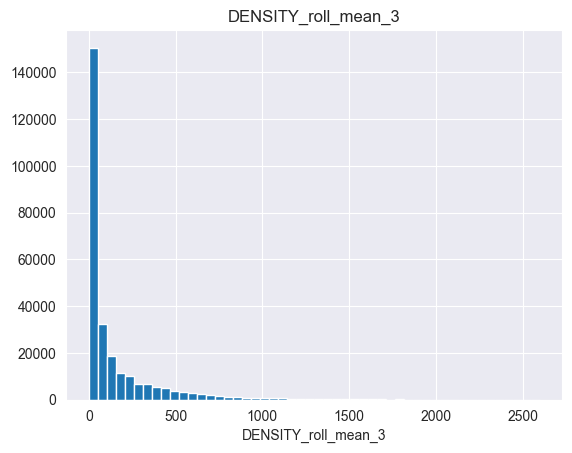

###########################
count   270608.000
mean        65.341
std        120.810
min          0.001
5%           0.915
10%          1.872
20%          3.757
30%          6.111
40%          9.490
50%         14.465
60%         23.176
70%         43.921
80%         90.180
90%        206.501
95%        324.240
99%        590.830
max       1444.750
Name: DENSITY_roll_std_3, dtype: float64


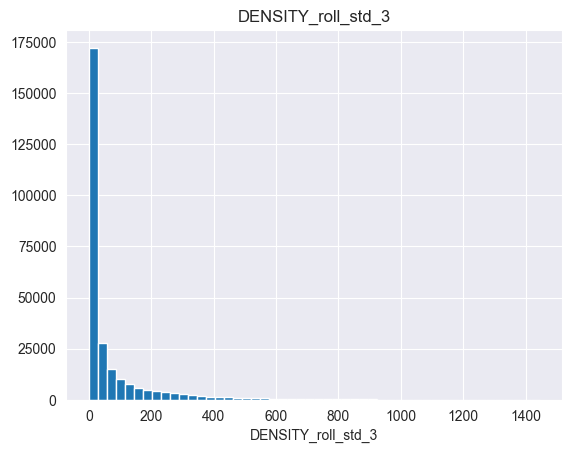

###########################
count   270807.000
mean       140.979
std        217.987
min          0.038
5%           2.361
10%          5.204
20%         10.089
30%         16.375
40%         25.562
50%         39.282
60%         65.565
70%        123.796
80%        227.725
90%        448.532
95%        624.099
99%        984.544
max       1756.591
Name: DENSITY_roll_mean_5, dtype: float64


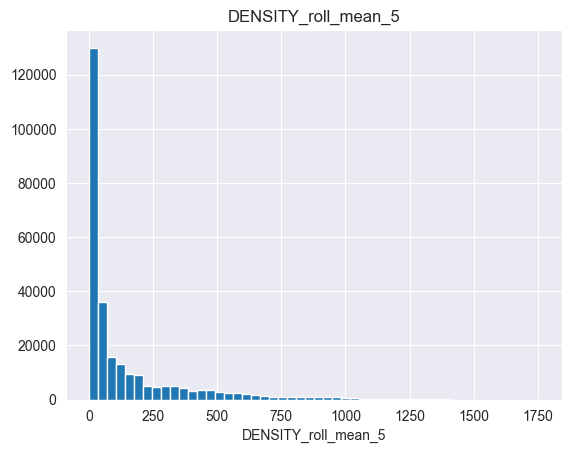

###########################
count   270608.000
mean        75.246
std        129.049
min          0.006
5%           1.403
10%          2.760
20%          5.093
30%          8.183
40%         12.041
50%         17.217
60%         28.356
70%         53.396
80%        114.861
90%        245.787
95%        356.314
99%        613.903
max       1250.435
Name: DENSITY_roll_std_5, dtype: float64


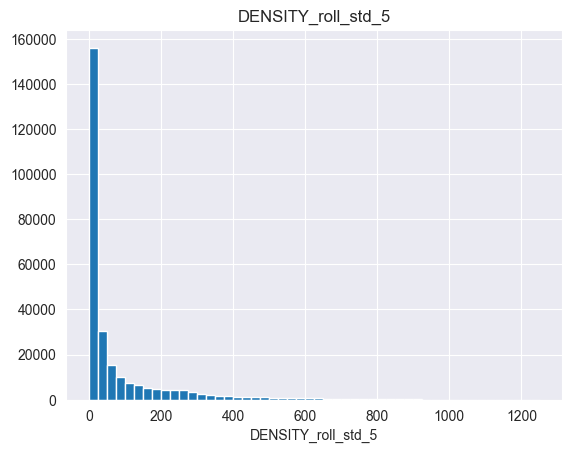

###########################
count   270807.000
mean       140.888
std        214.674
min          0.038
5%           2.487
10%          5.310
20%         10.345
30%         16.717
40%         25.622
50%         39.649
60%         66.277
70%        125.185
80%        235.512
90%        448.647
95%        617.526
99%        966.420
max       1744.263
Name: DENSITY_roll_mean_10, dtype: float64


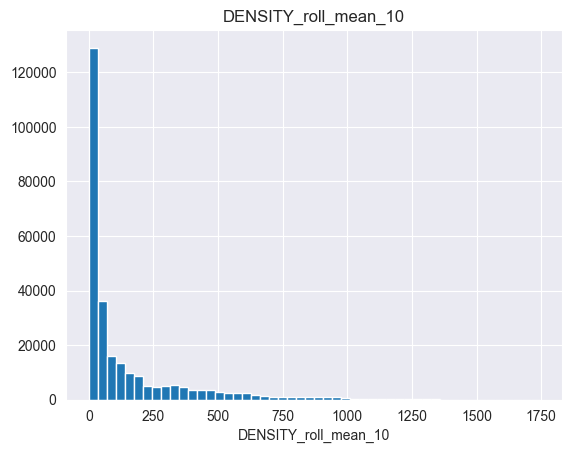

###########################
count   270608.000
mean        75.480
std        125.144
min          0.006
5%           1.526
10%          2.974
20%          5.476
30%          8.630
40%         12.319
50%         17.545
60%         28.981
70%         55.454
80%        120.663
90%        245.693
95%        350.382
99%        579.398
max       1150.139
Name: DENSITY_roll_std_10, dtype: float64


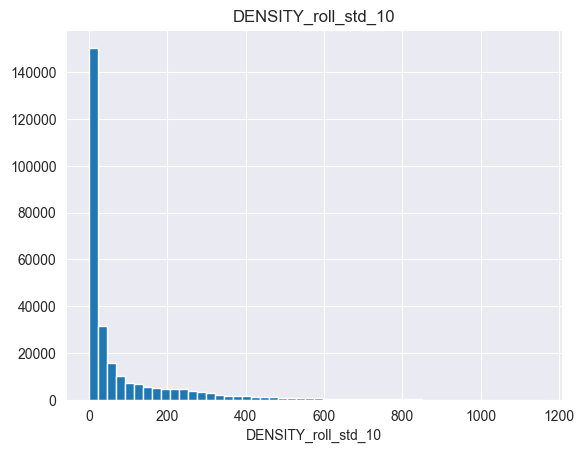

###########################
count   270807.000
mean       140.641
std        209.376
min          0.038
5%           2.558
10%          5.424
20%         10.555
30%         16.921
40%         25.738
50%         40.502
60%         65.927
70%        126.426
80%        248.139
90%        450.114
95%        619.747
99%        894.418
max       1343.775
Name: DENSITY_roll_mean_35, dtype: float64


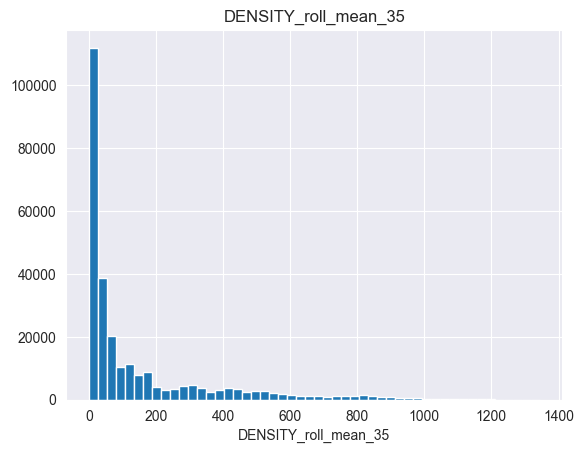

###########################
count   270608.000
mean        77.543
std        126.073
min          0.006
5%           1.578
10%          3.053
20%          5.655
30%          8.999
40%         12.807
50%         18.432
60%         29.836
70%         58.948
80%        125.954
90%        250.529
95%        363.535
99%        576.468
max        962.967
Name: DENSITY_roll_std_35, dtype: float64


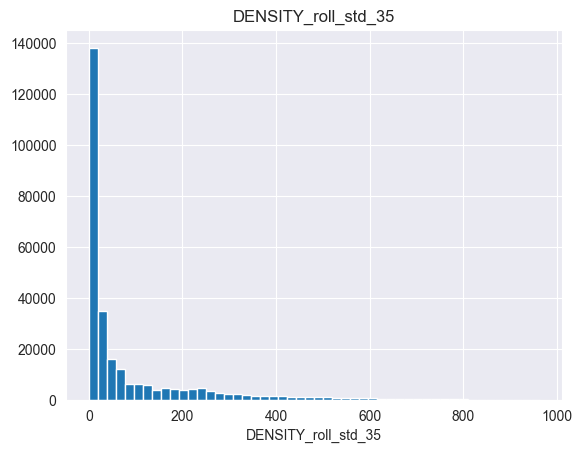

###########################
count   271006.000
mean        41.088
std          0.113
min         40.759
5%          40.891
10%         40.935
20%         40.979
30%         41.023
40%         41.067
50%         41.111
60%         41.111
70%         41.155
80%         41.199
90%         41.243
95%         41.243
99%         41.331
max         41.331
Name: lat, dtype: float64


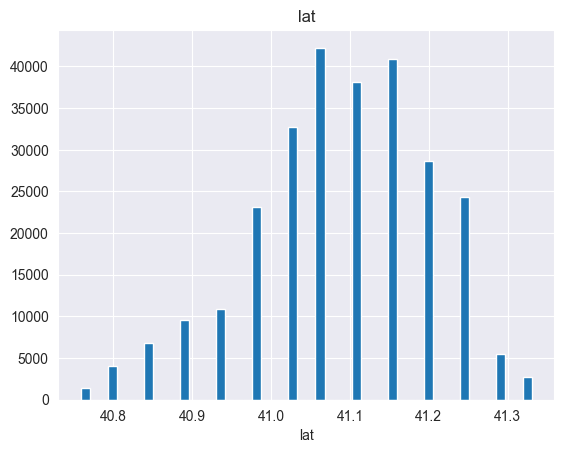

###########################
count   271006.000
mean        28.812
std          0.428
min         27.971
5%          28.015
10%         28.103
20%         28.411
30%         28.586
40%         28.718
50%         28.850
60%         28.982
70%         29.114
80%         29.202
90%         29.333
95%         29.421
99%         29.597
max         29.641
Name: lon, dtype: float64


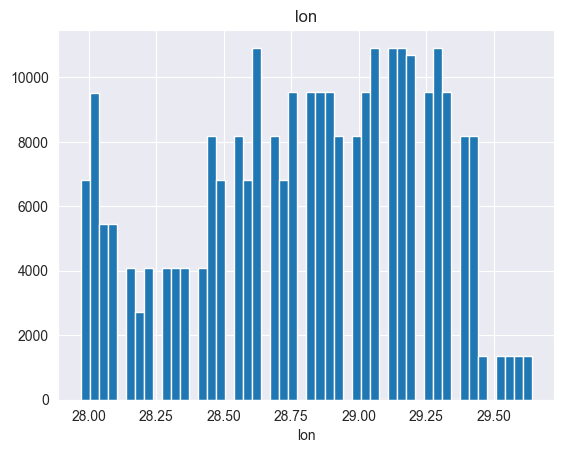

###########################


In [12]:
def num_sumamry(dataframe, numerical_col, plot=True):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=50)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

    print("###########################")

for col in num_cols:
    num_sumamry(veri, col, True)

Hedef Değişken Analizi

In [13]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}),end="\n\n\n")

for col in cat_cols:
    target_summary_with_cat(veri,"DENSITY",col)

              TARGET_MEAN
TIME_PERIOD              
Daytime           229.125
Evening_Peak      172.182
Late_Evening       93.309
Morning_Peak      154.093
Night              57.106


                    TARGET_MEAN
rainfall_condition             
Hafif Yağmur            144.396
Sağanak                 158.751
Yağışlı                  82.189
Yağışsız                139.016


                 TARGET_MEAN
TIME_PERIOD_STR             
daytime              229.125
evening_peak         172.182
late_evening          93.309
morning_peak         154.093
night                 57.106


               TARGET_MEAN
haftanin_gunu             
0                  149.164
1                  158.590
2                  155.757
3                  160.840
4                  162.387
5                  124.221
6                   79.186


               TARGET_MEAN
hafta_sonu_mu             
0                  157.293
1                  100.787


                 TARGET_MEAN
TIME_PERIOD_NUM             
0   

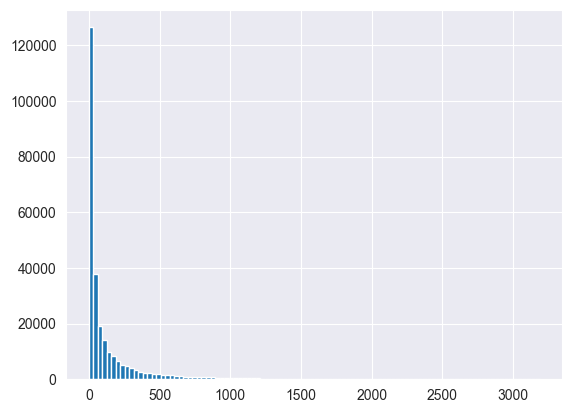

In [14]:
# Başarılı değişkenin incelenmesi
veri["DENSITY"].hist(bins=100)
plt.show(block=True)

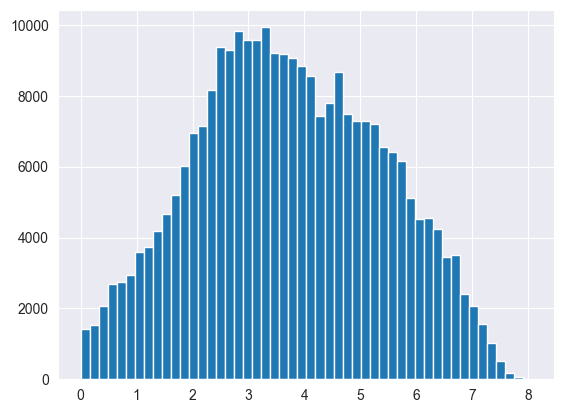

In [15]:
#Bağımlı değişkenin logaritmasının incelenmesi
np.log1p(veri["DENSITY"]).hist(bins=50)
plt.show(block=True)

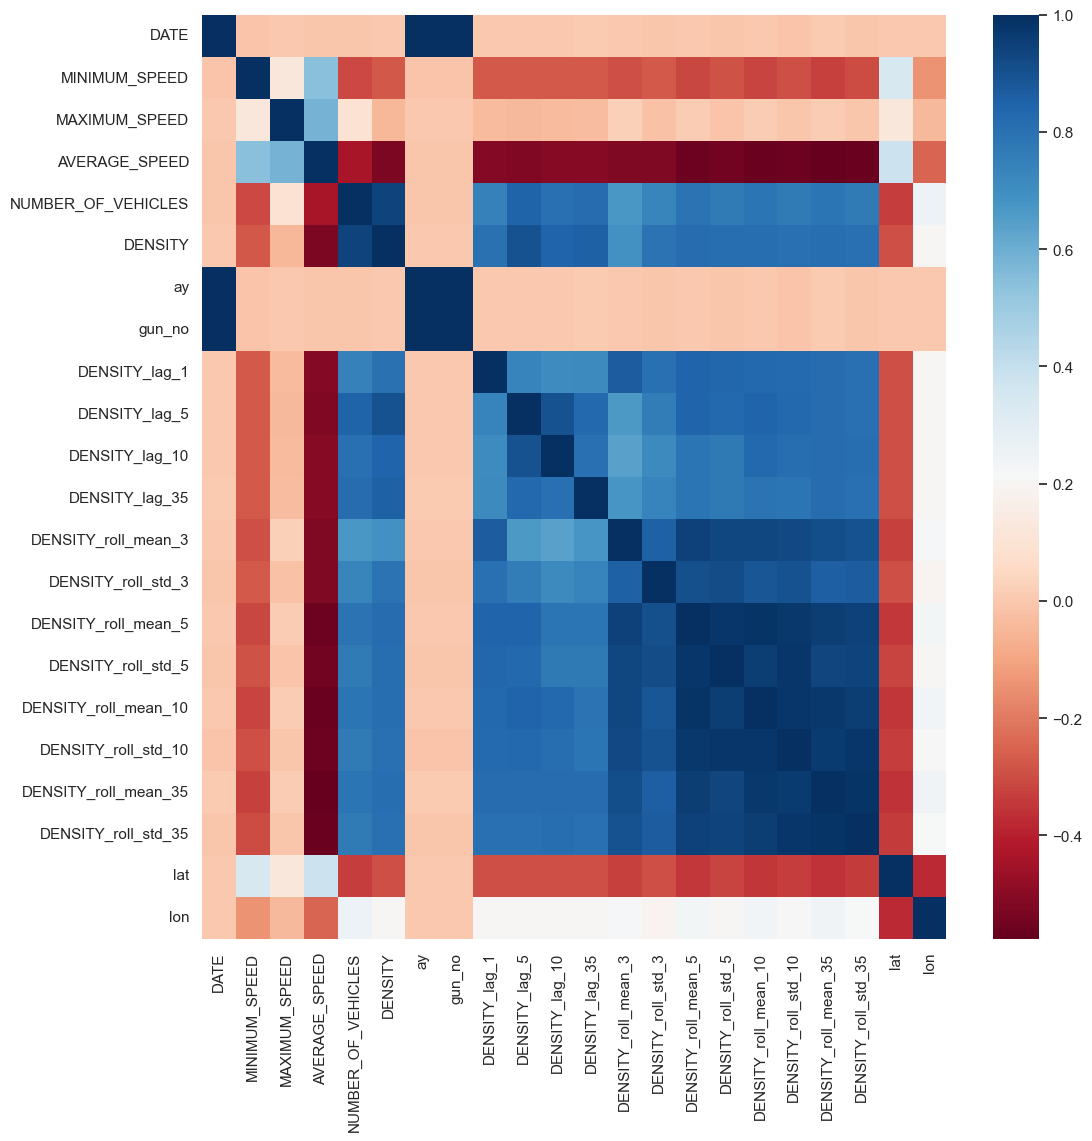

In [16]:
corr = veri[num_cols].corr()
corr
sns.set_theme(rc={'figure.figsize':(12,12)})
sns.heatmap(corr,cmap="RdBu")
plt.show()

Eksik Değer Analizi

In [17]:
missing_data = veri.isnull().sum()
print("Eksik Kayıp Veri Tablosu:")
print(missing_data)

Eksik Kayıp Veri Tablosu:
GEOHASH_SHORT              0
DATE                       0
TIME_PERIOD                0
MINIMUM_SPEED              0
MAXIMUM_SPEED              0
AVERAGE_SPEED              0
NUMBER_OF_VEHICLES         0
rainfall_condition         0
DENSITY                    0
haftanin_gunu              0
ay                         0
gun_no                     0
hafta_sonu_mu              0
TIME_PERIOD_STR            0
TIME_PERIOD_NUM            0
DENSITY_lag_1            199
DENSITY_lag_5            995
DENSITY_lag_10          1990
DENSITY_lag_35          6965
DENSITY_roll_mean_3      199
DENSITY_roll_std_3       398
DENSITY_roll_mean_5      199
DENSITY_roll_std_5       398
DENSITY_roll_mean_10     199
DENSITY_roll_std_10      398
DENSITY_roll_mean_35     199
DENSITY_roll_std_35      398
lat                        0
lon                        0
dtype: int64


Aykırı Değer Analizi

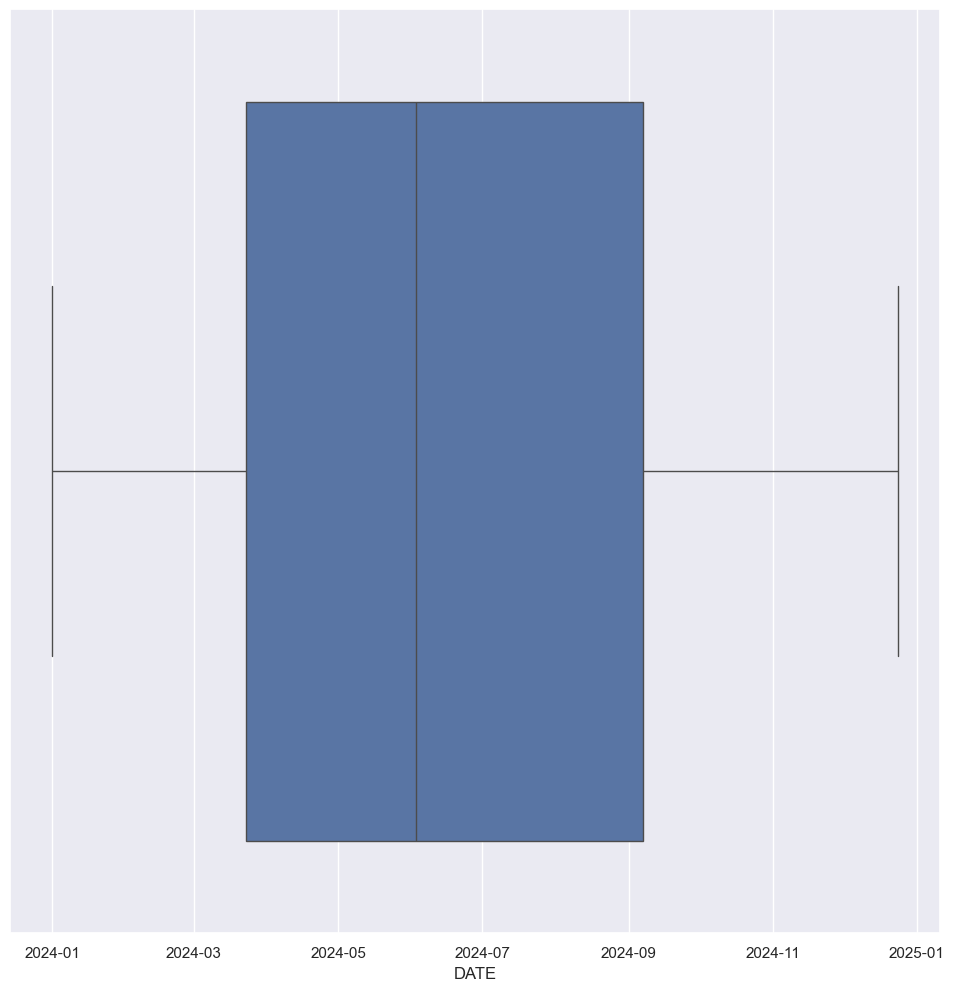

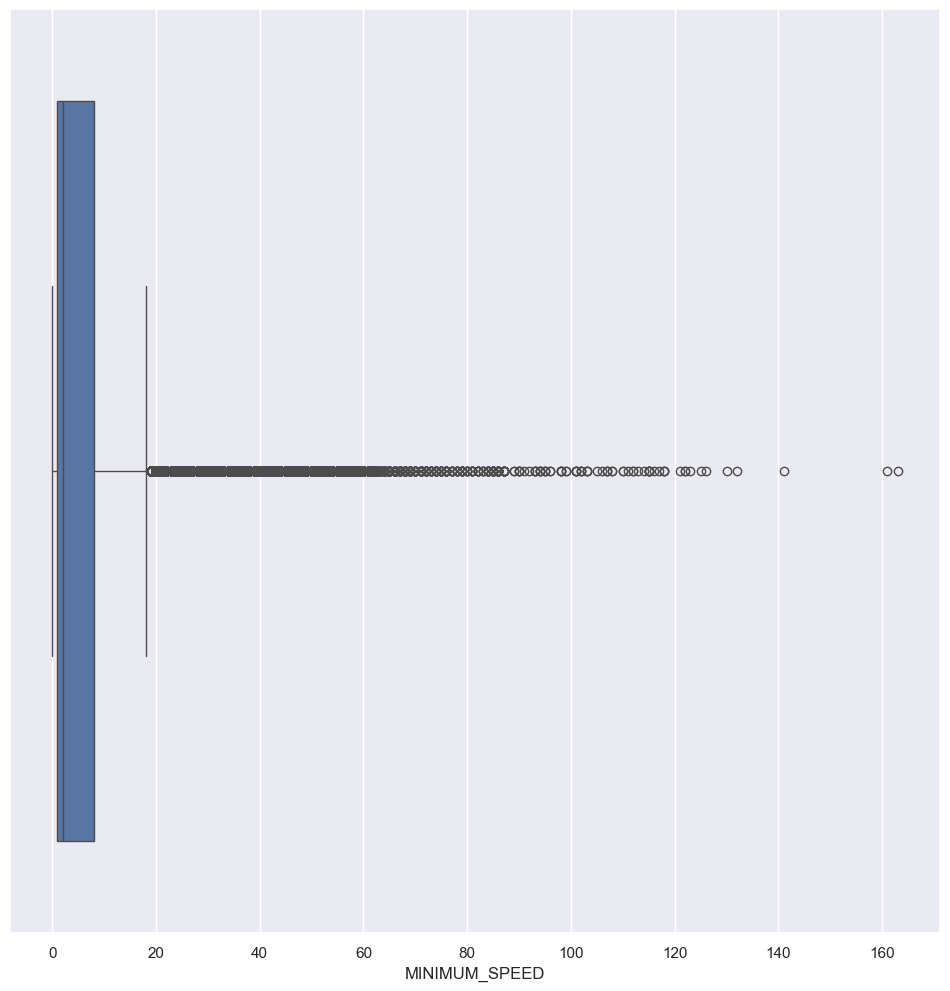

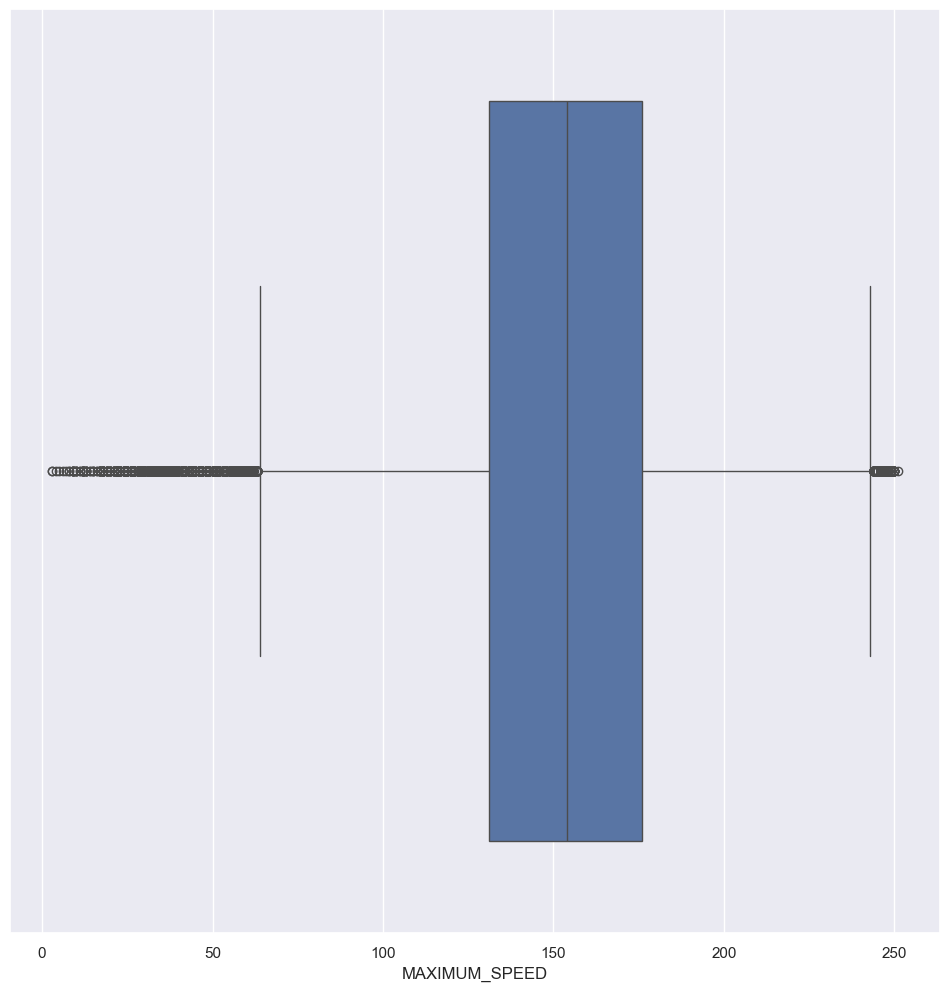

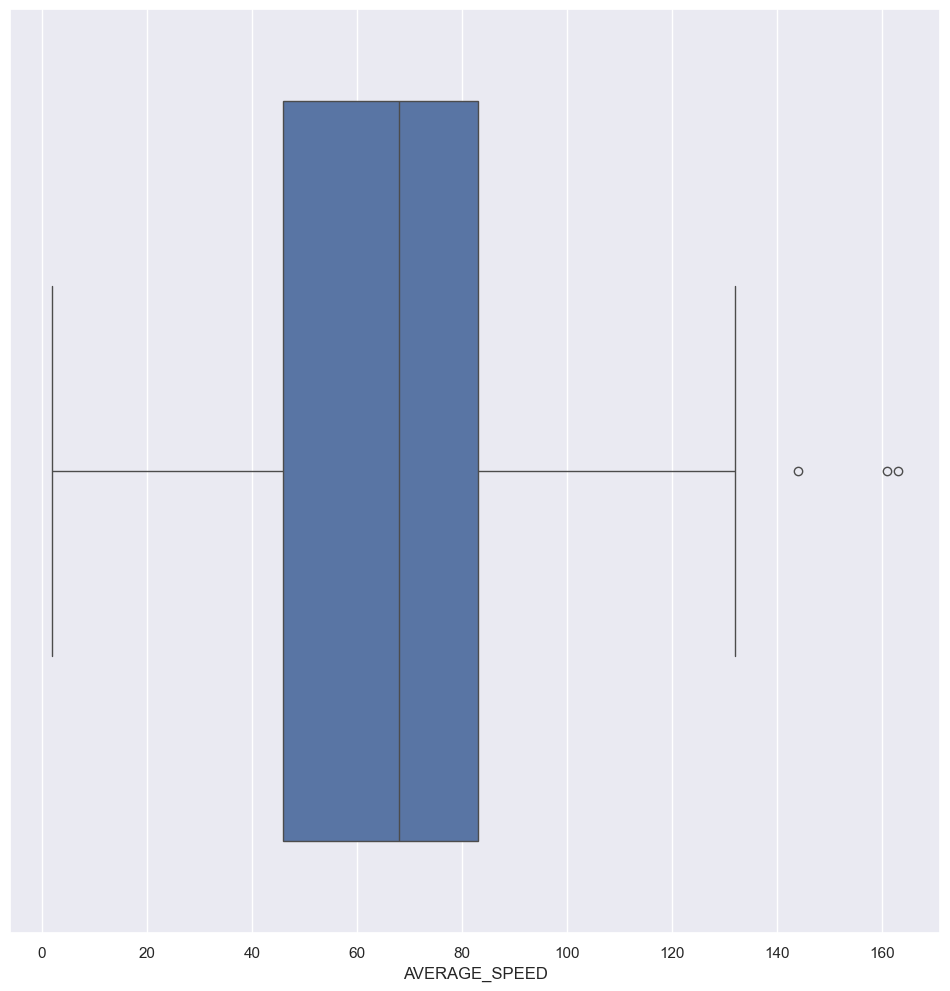

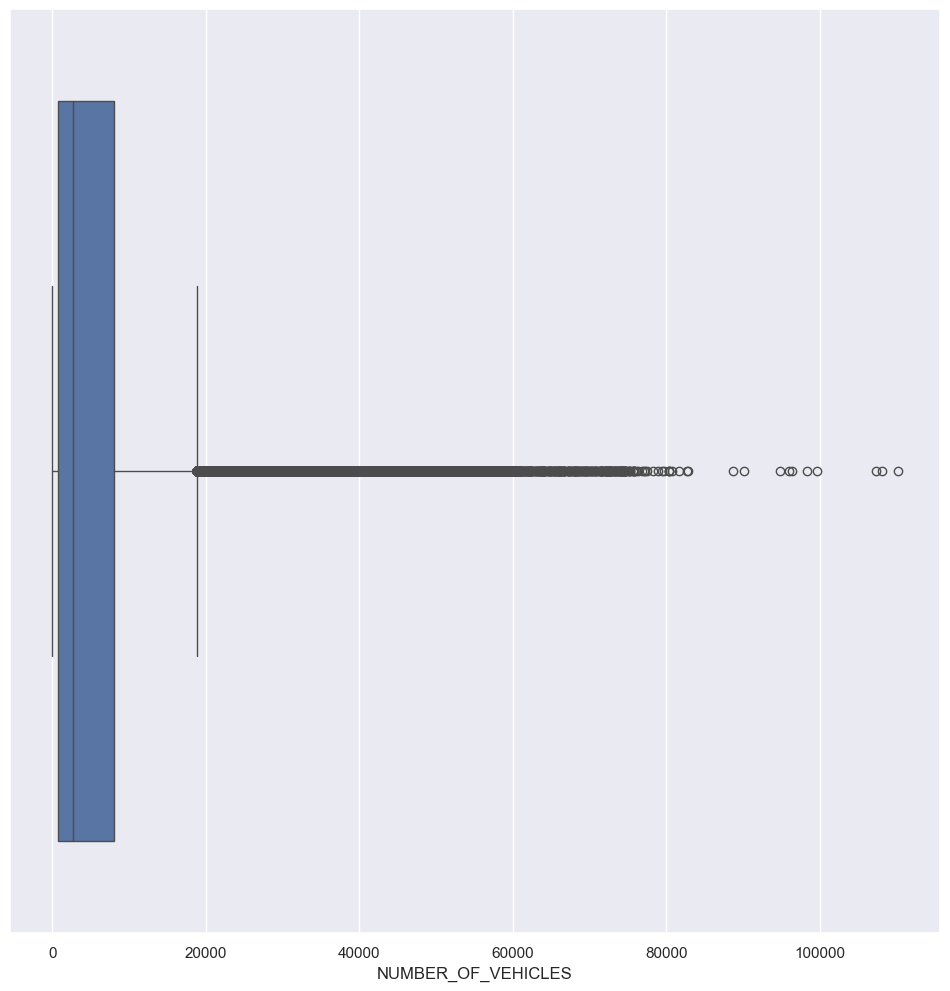

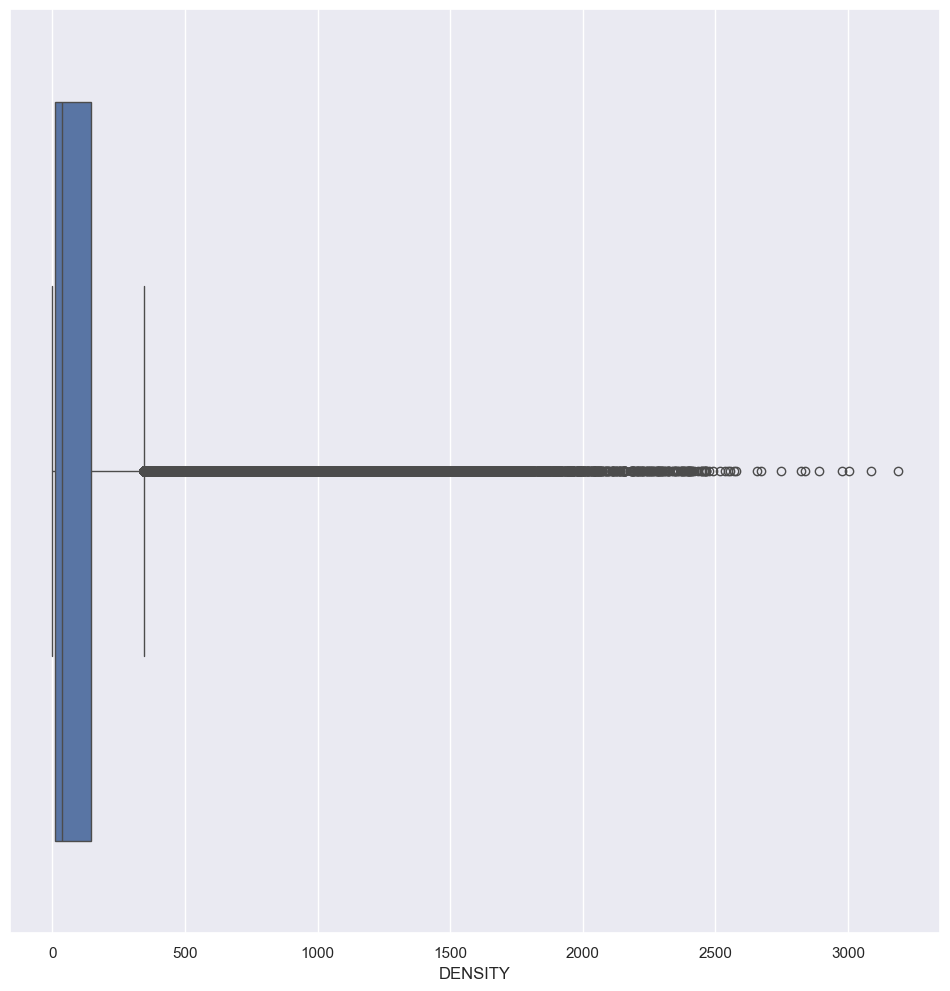

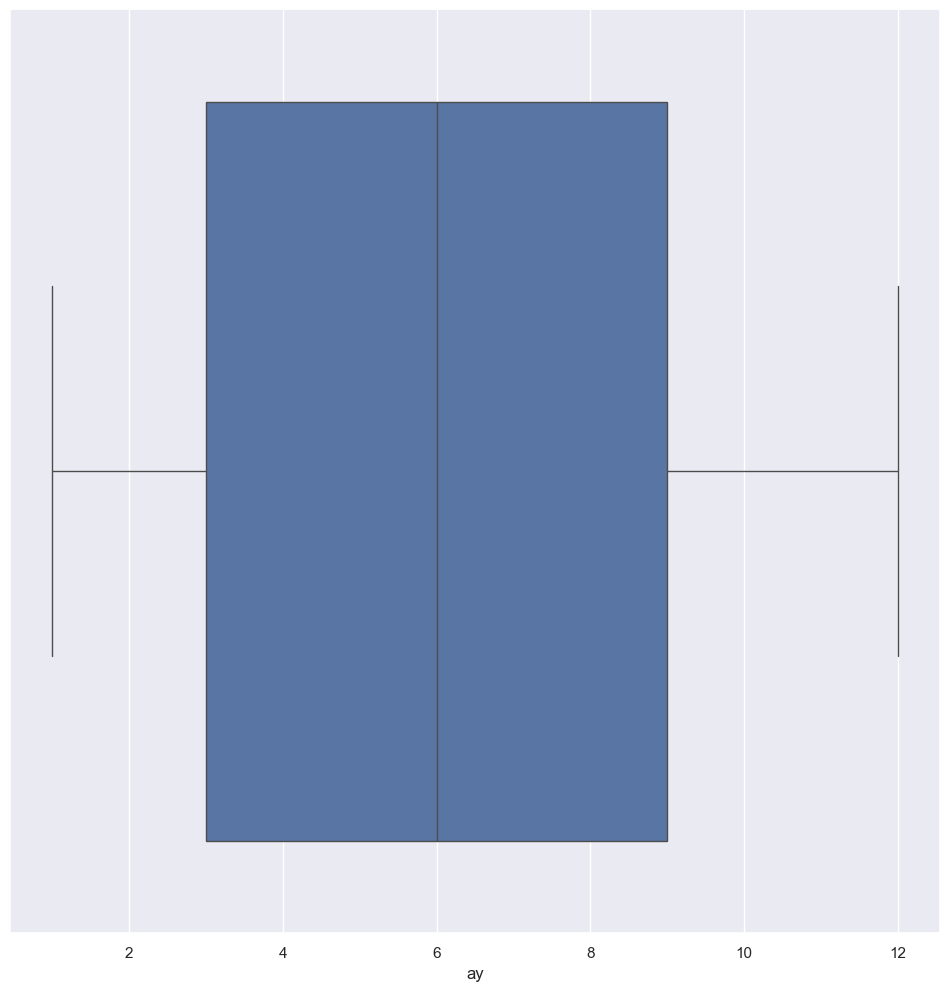

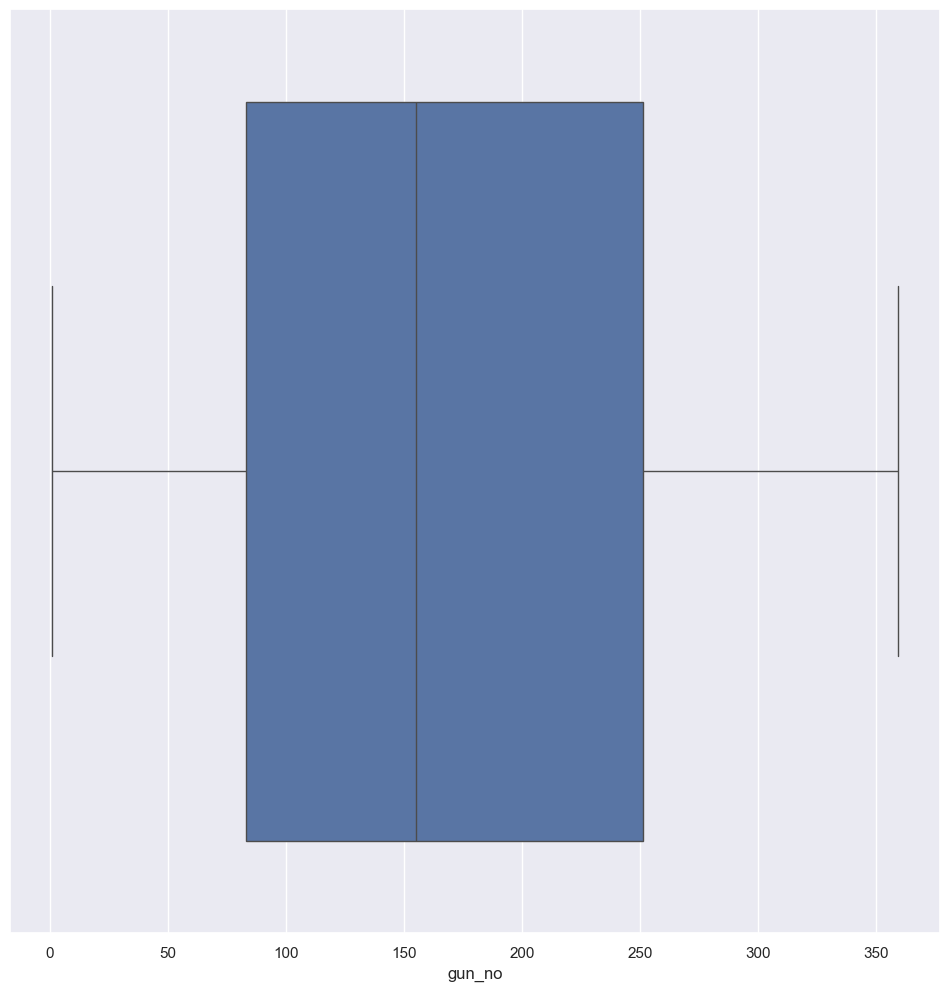

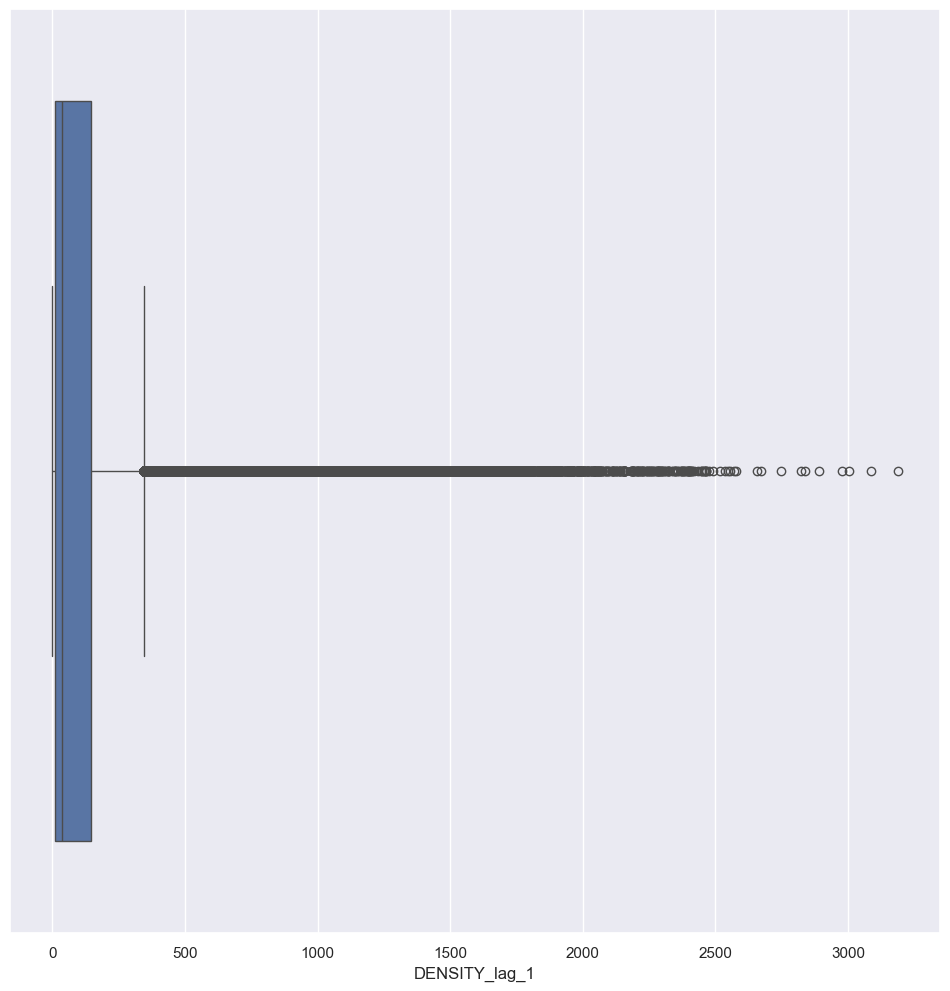

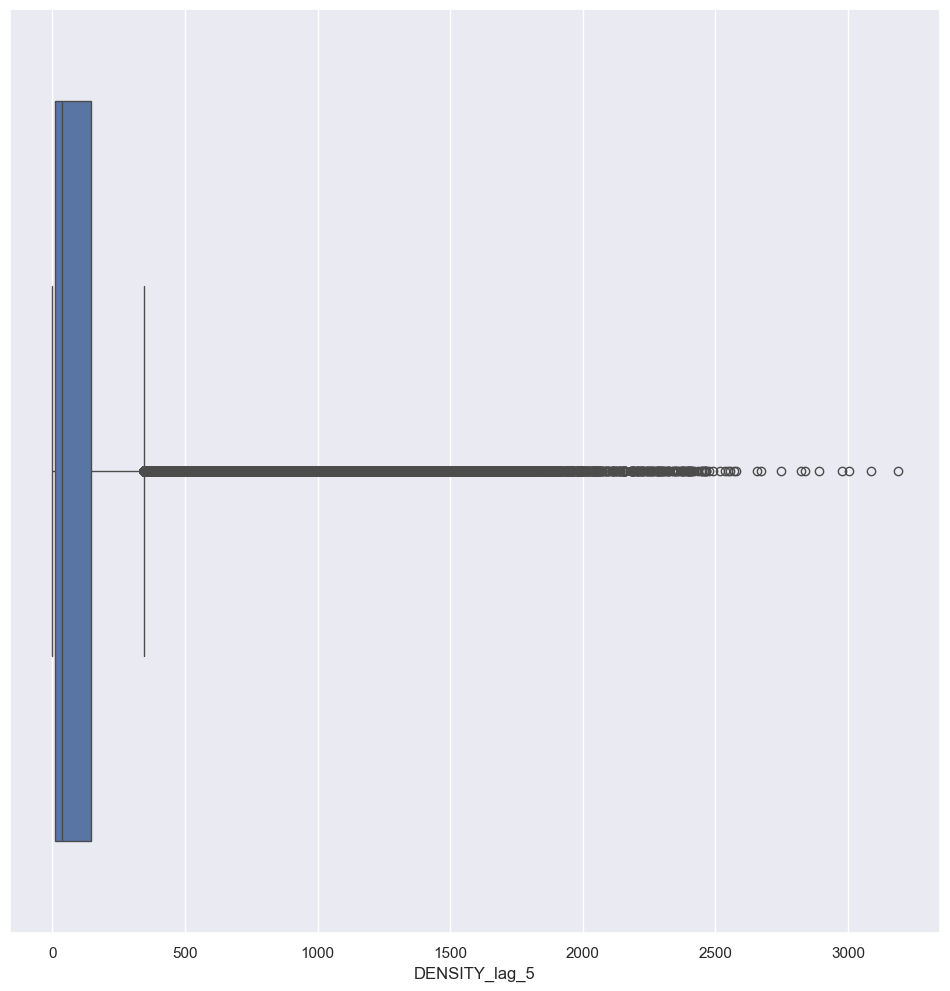

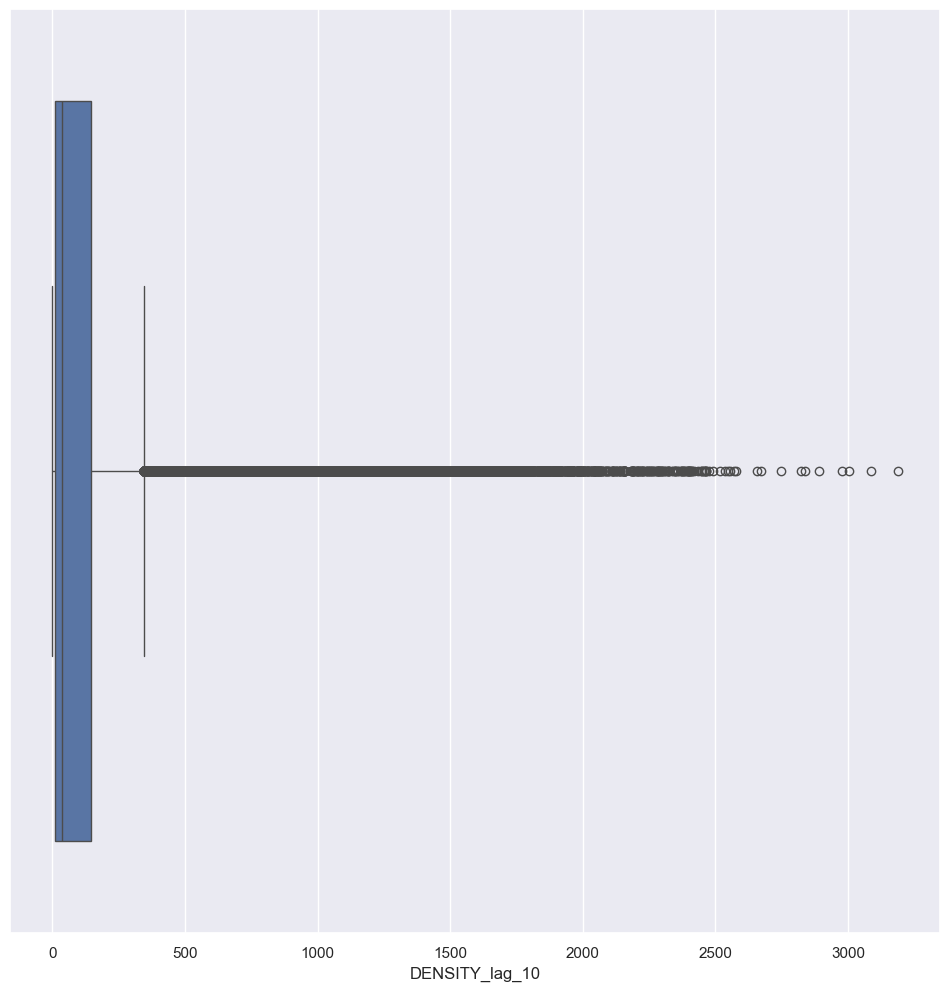

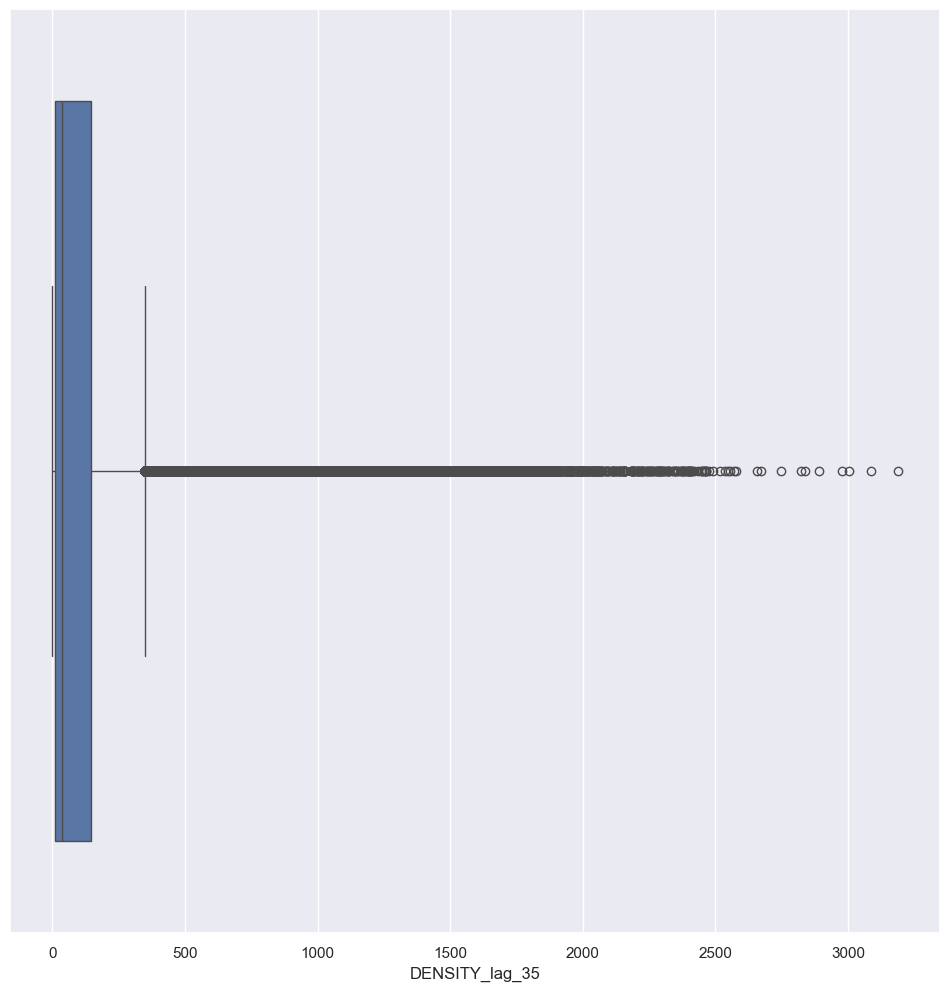

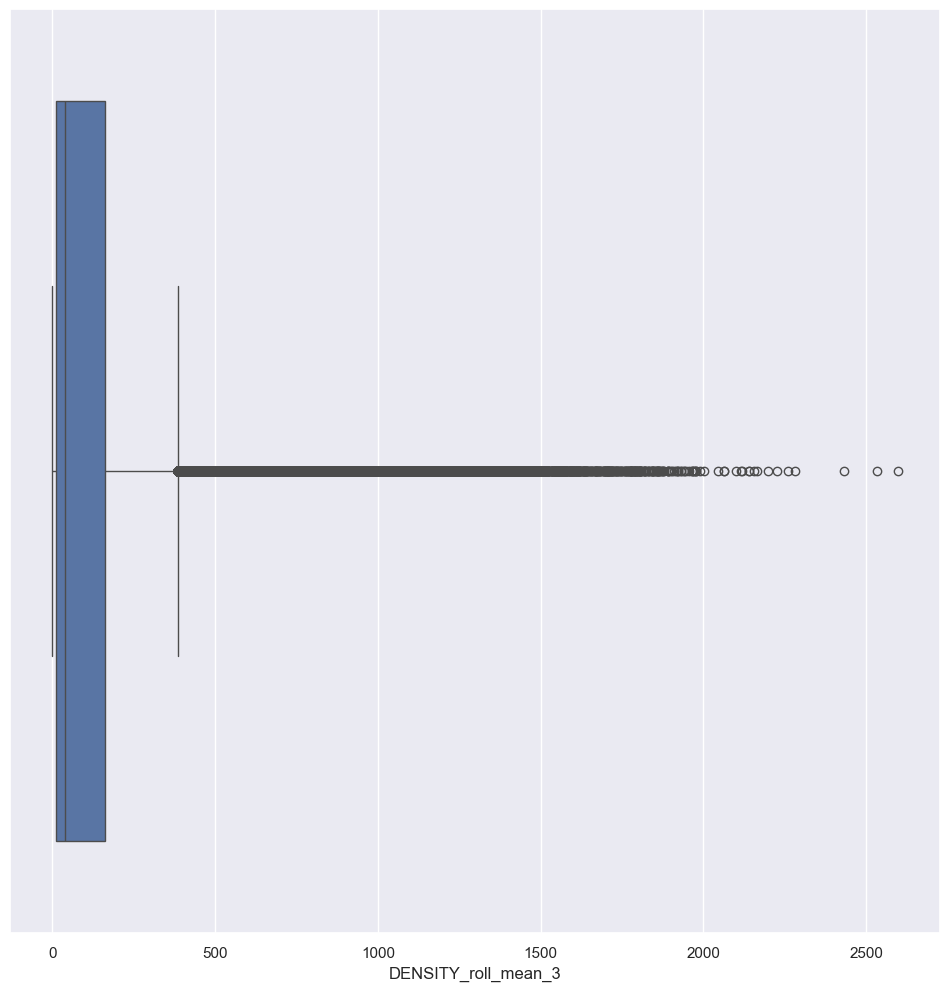

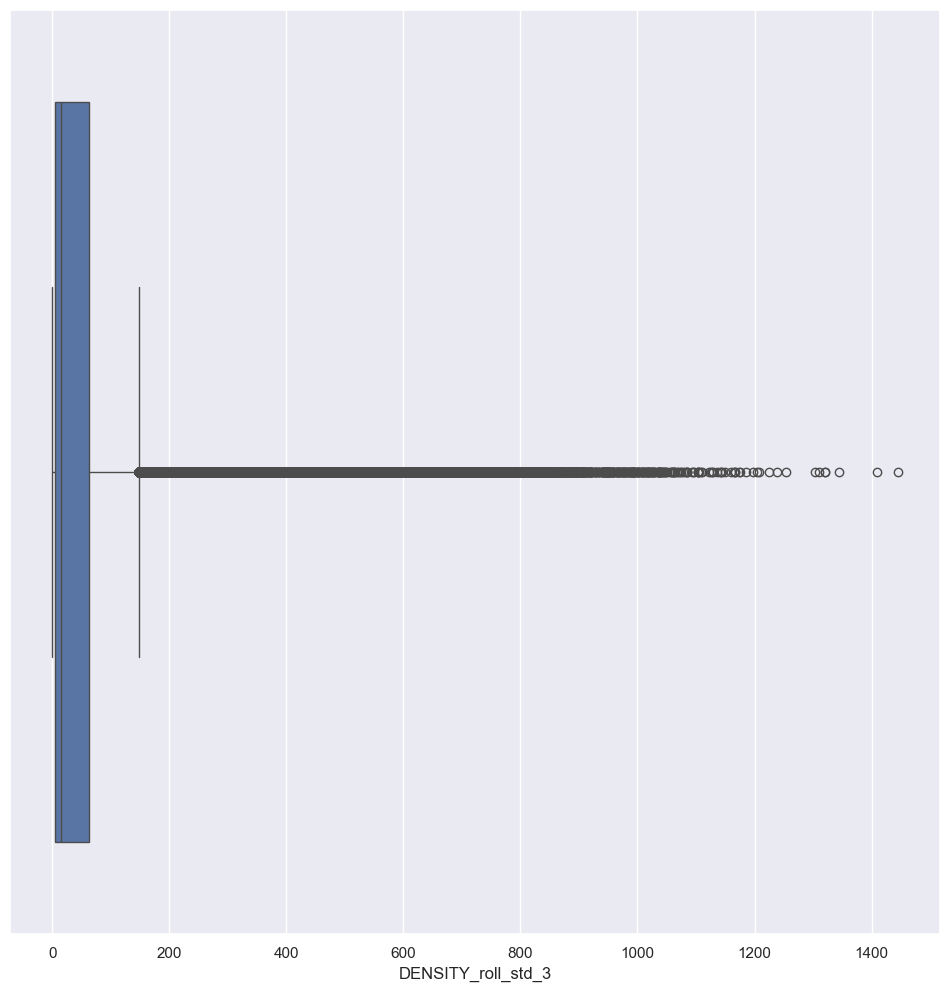

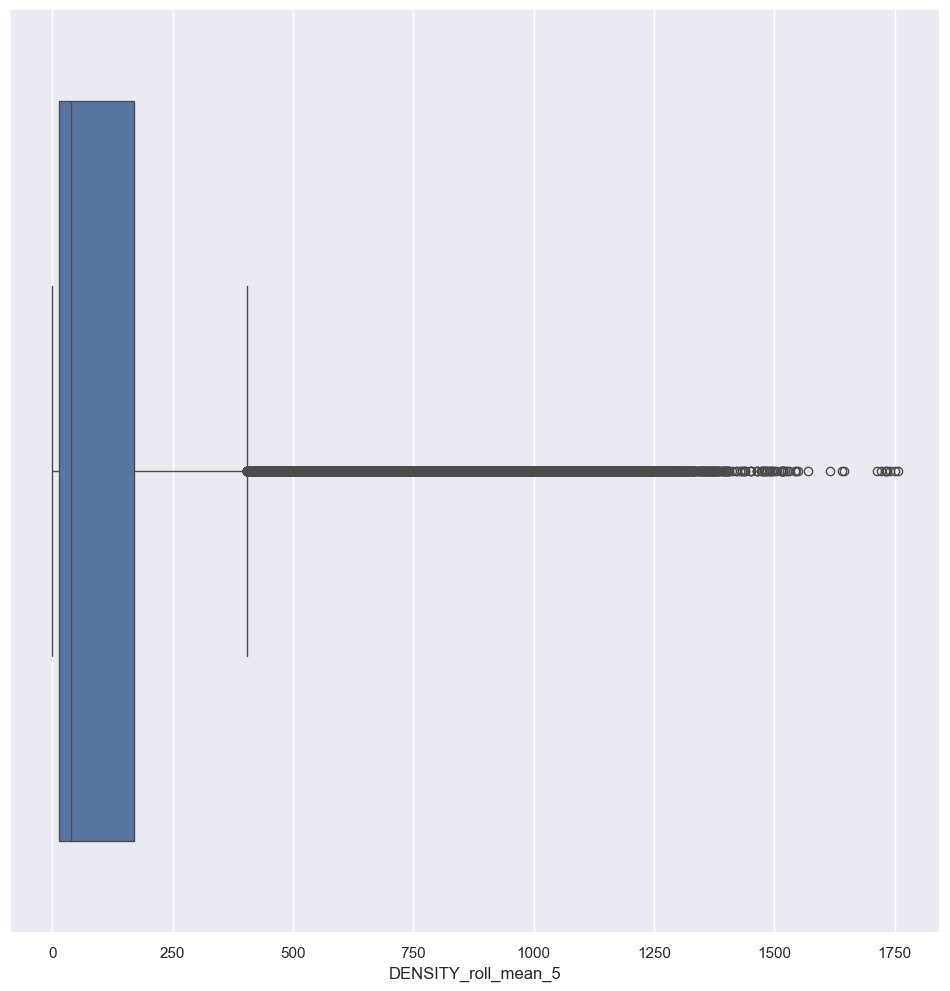

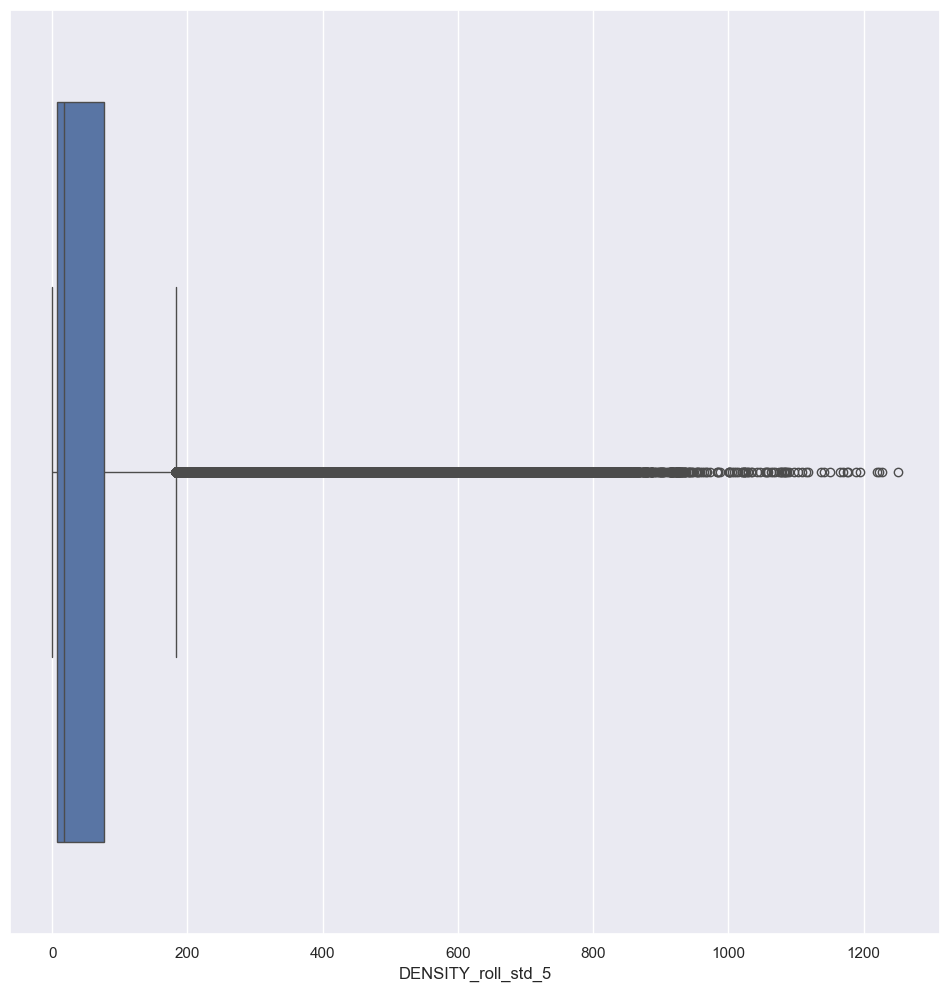

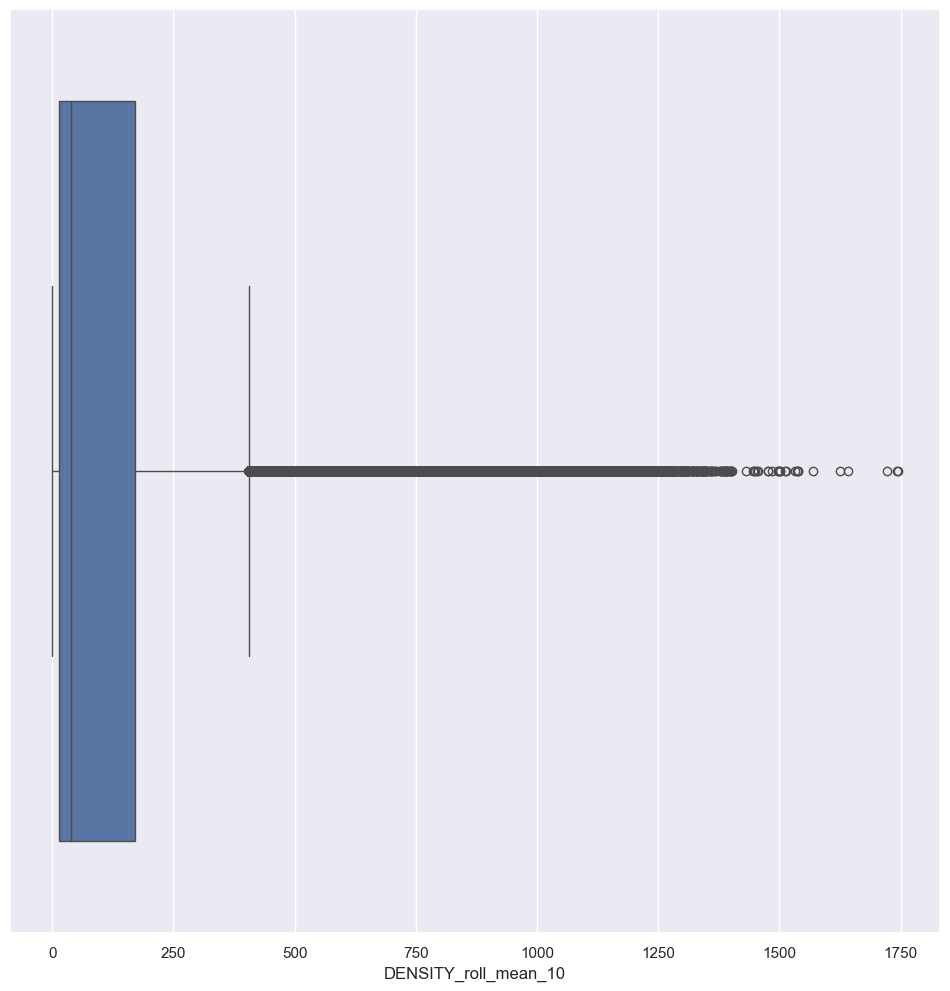

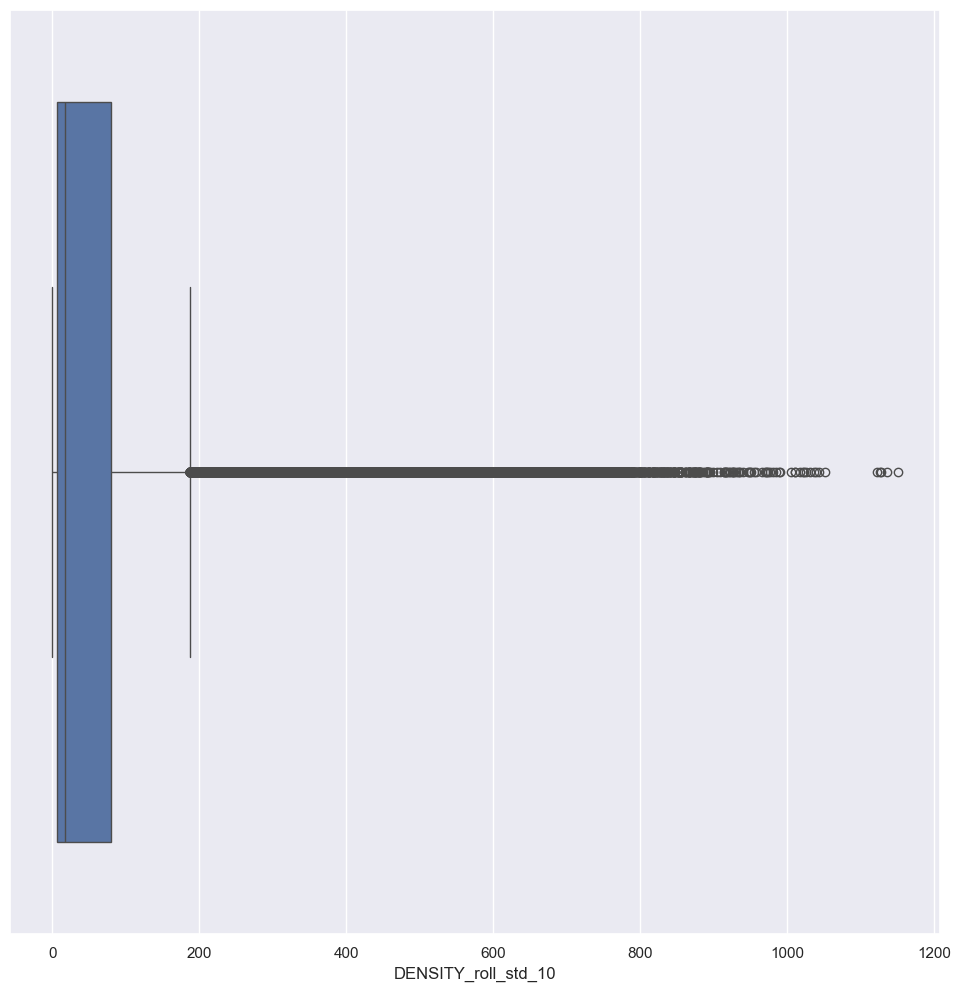

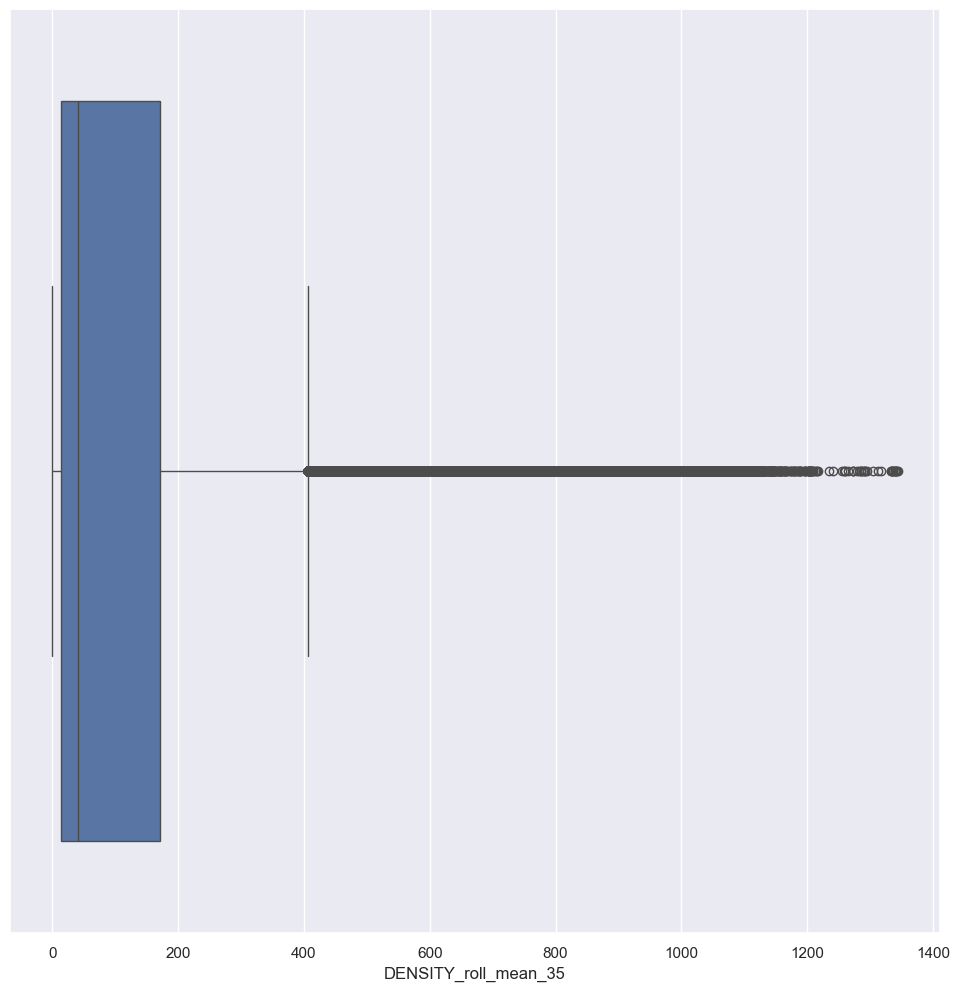

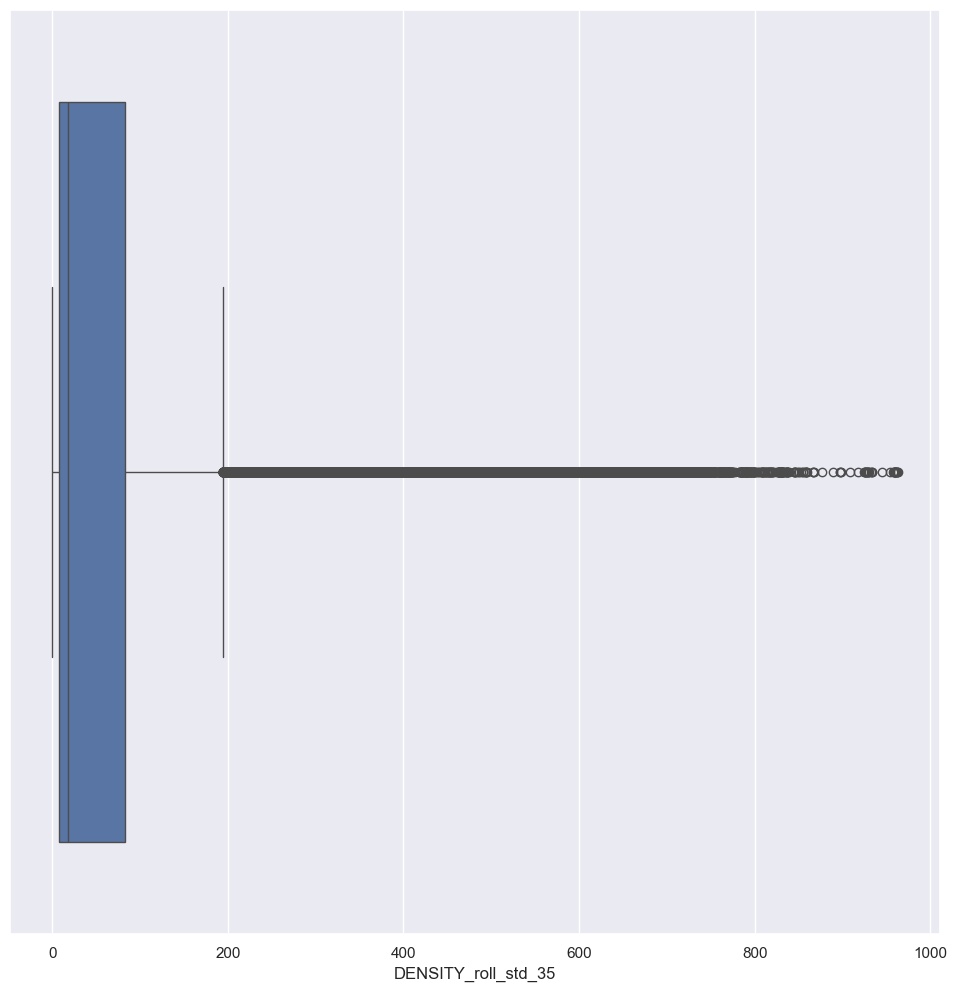

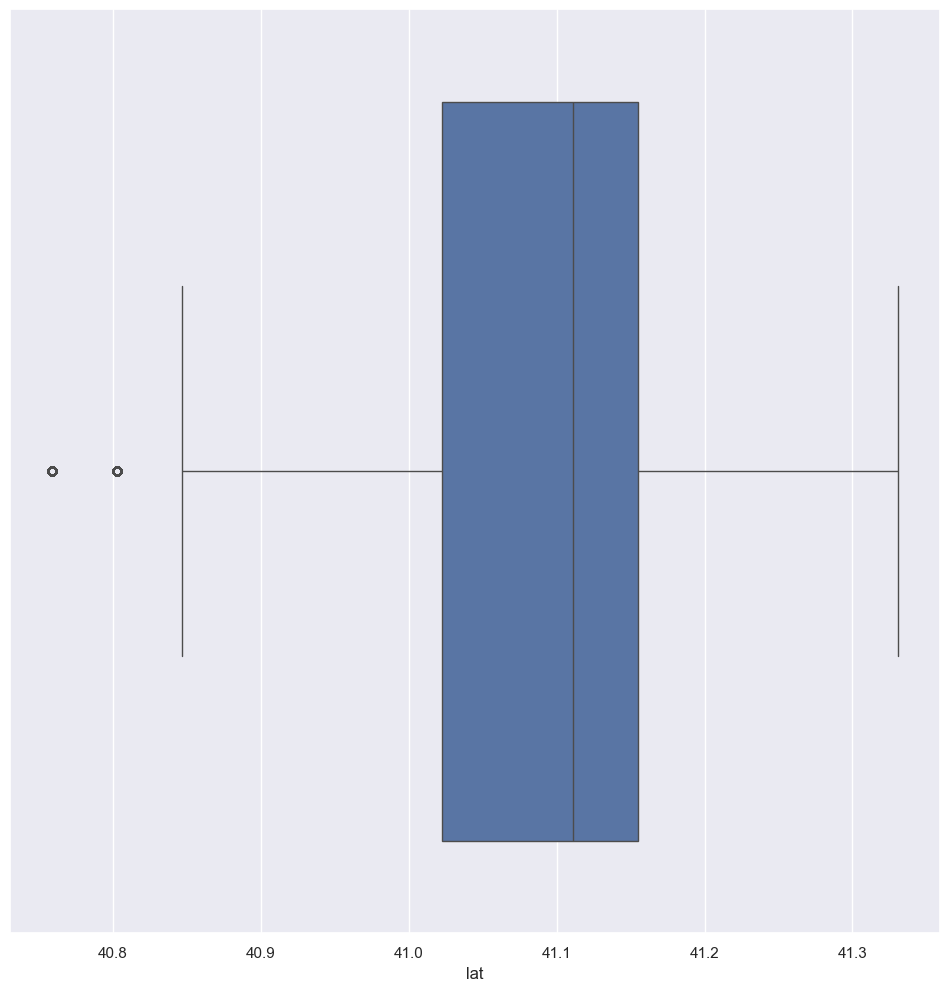

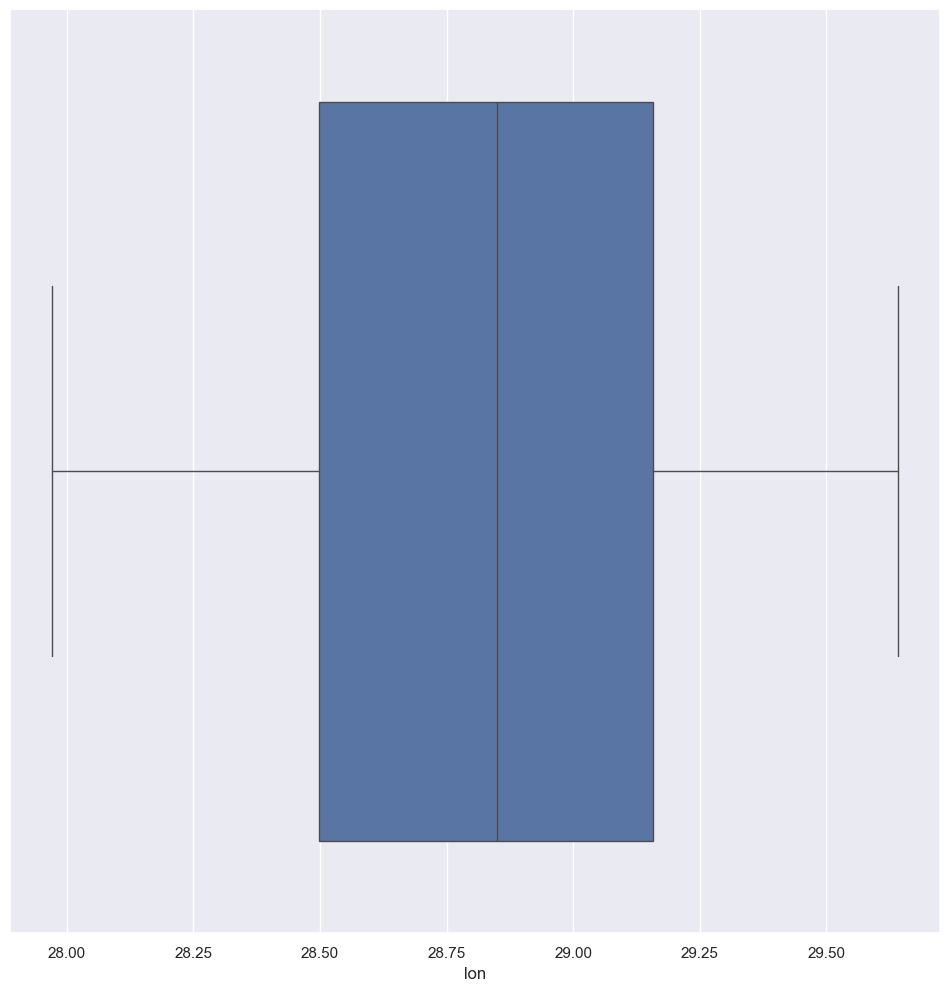

In [18]:
for col in num_cols:
    sns.boxplot(x=veri[col])
    plt.show()

In [19]:
def outlier_thresholds(veri, variable, q1=0.25, q3=0.75):
    quantile1 = veri[variable].quantile(q1)
    quantile3 = veri[variable].quantile(q3)
    iqr = quantile3 - quantile1
    low_limit = quantile1 - 1.5 * iqr
    up_limit = quantile3 + 1.5 * iqr
    return low_limit, up_limit

In [20]:
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name]>up_limit) | (dataframe[col_name]<low_limit)].any(axis=None):
        return True
    else:
        return False

In [21]:
for col in num_cols:
    if col != "DENSITY":
        print(col, check_outlier(veri,col))

DATE False
MINIMUM_SPEED True
MAXIMUM_SPEED True
AVERAGE_SPEED True
NUMBER_OF_VEHICLES True
ay False
gun_no False
DENSITY_lag_1 True
DENSITY_lag_5 True
DENSITY_lag_10 True
DENSITY_lag_35 True
DENSITY_roll_mean_3 True
DENSITY_roll_std_3 True
DENSITY_roll_mean_5 True
DENSITY_roll_std_5 True
DENSITY_roll_mean_10 True
DENSITY_roll_std_10 True
DENSITY_roll_mean_35 True
DENSITY_roll_std_35 True
lat True
lon False


In [22]:
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable]<low_limit),variable] = low_limit
    dataframe.loc[(dataframe[variable]>up_limit),variable]=up_limit

In [23]:
for col in num_cols:
    if col!="DENSITY":
        replace_with_thresholds(veri,col)

In [24]:
for col in num_cols:
    if col != "DENSITY":
        print(col, check_outlier(veri,col))

DATE False
MINIMUM_SPEED False
MAXIMUM_SPEED False
AVERAGE_SPEED False
NUMBER_OF_VEHICLES False
ay False
gun_no False
DENSITY_lag_1 False
DENSITY_lag_5 False
DENSITY_lag_10 False
DENSITY_lag_35 False
DENSITY_roll_mean_3 False
DENSITY_roll_std_3 False
DENSITY_roll_mean_5 False
DENSITY_roll_std_5 False
DENSITY_roll_mean_10 False
DENSITY_roll_std_10 False
DENSITY_roll_mean_35 False
DENSITY_roll_std_35 False
lat False
lon False


Kategorik kolonların dağılımının incelenmesi

In [25]:
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                            "RATIO": dataframe[col].value_counts() / len(dataframe),
                            "TARGET_MEAN": dataframe.groupby(col)[target].mean()}), end="\n\n\n")
rare_analyser(veri, "DENSITY", cat_cols)

TIME_PERIOD : 5
              COUNT  RATIO  TARGET_MEAN
TIME_PERIOD                            
Daytime       54205  0.200      229.125
Evening_Peak  53731  0.198      172.182
Late_Evening  52353  0.193       93.309
Morning_Peak  55099  0.203      154.093
Night         55618  0.205       57.106


rainfall_condition : 4
                     COUNT  RATIO  TARGET_MEAN
rainfall_condition                            
Hafif Yağmur         97862  0.361      144.396
Sağanak               3978  0.015      158.751
Yağışlı                994  0.004       82.189
Yağışsız            168172  0.621      139.016


TIME_PERIOD_STR : 5
                 COUNT  RATIO  TARGET_MEAN
TIME_PERIOD_STR                           
daytime          54205  0.200      229.125
evening_peak     53731  0.198      172.182
late_evening     52353  0.193       93.309
morning_peak     55099  0.203      154.093
night            55618  0.205       57.106


haftanin_gunu : 7
               COUNT  RATIO  TARGET_MEAN
haftanin_gunu

GÖRSELLEŞTİRMELER

Average speed over time by rain condition

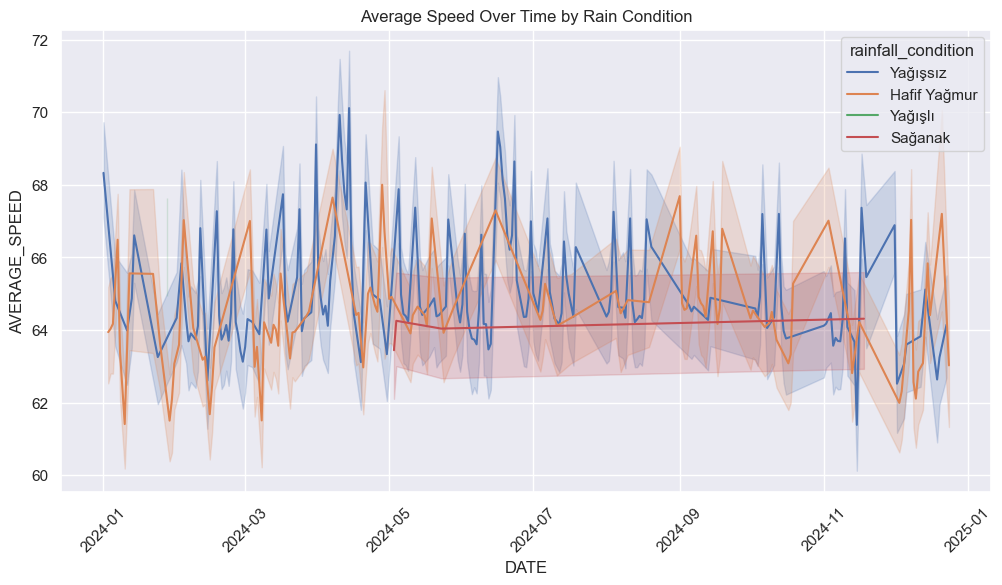

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=veri, x='DATE', y='AVERAGE_SPEED', hue='rainfall_condition')
plt.title('Average Speed Over Time by Rain Condition')
plt.xticks(rotation=45)
plt.show()

Correlation heatmap

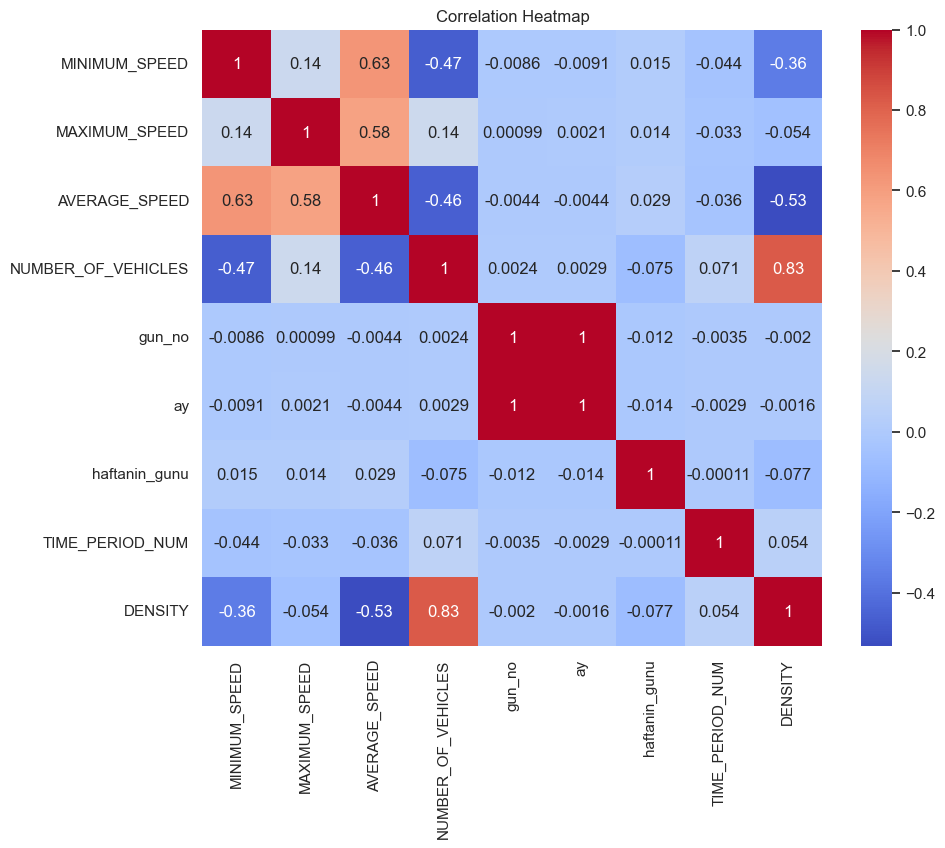

In [28]:
numerical_cols = ['MINIMUM_SPEED', 'MAXIMUM_SPEED', 'AVERAGE_SPEED', 'NUMBER_OF_VEHICLES', 'gun_no', 'ay', 'haftanin_gunu', 'TIME_PERIOD_NUM',"DENSITY"]
corr = veri[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Distribution of target variable

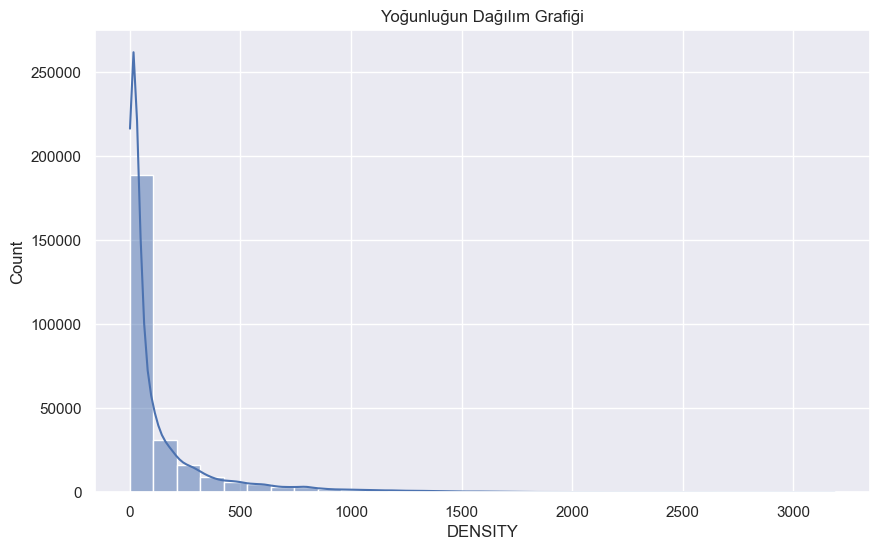

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(veri['DENSITY'], kde=True, bins=30)
plt.title('Yoğunluğun Dağılım Grafiği')
plt.show()

Yoğunluk vs Ortalama Hız

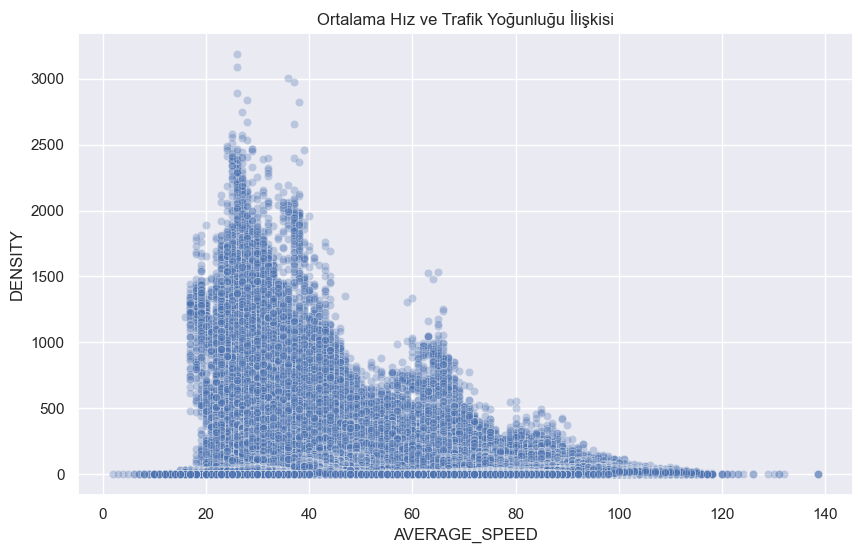

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=veri, x="AVERAGE_SPEED", y="DENSITY", alpha=0.3)
plt.title("Ortalama Hız ve Trafik Yoğunluğu İlişkisi")
plt.show()

Araç Sayısı vs Yoğunluk

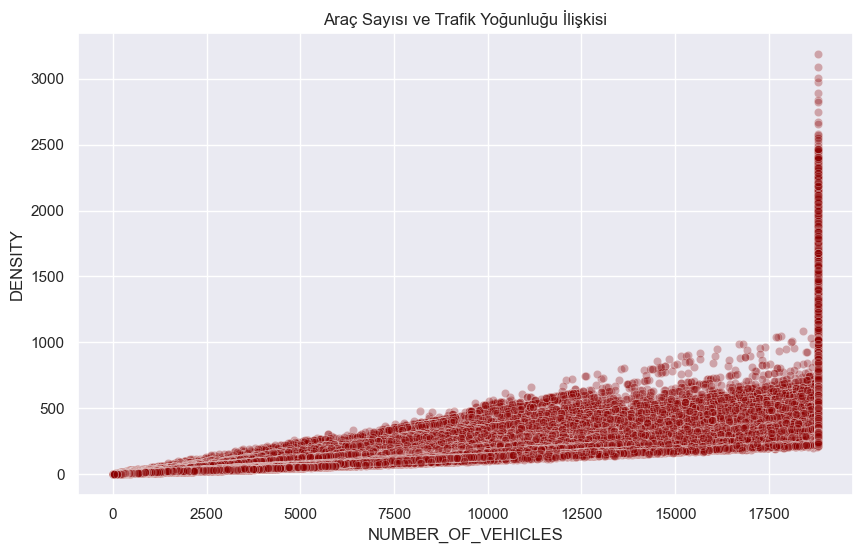

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=veri, x="NUMBER_OF_VEHICLES", y="DENSITY", alpha=0.3, color="darkred")
plt.title("Araç Sayısı ve Trafik Yoğunluğu İlişkisi")
plt.show()

Yağış Durumuna Göre Ortalama Hız

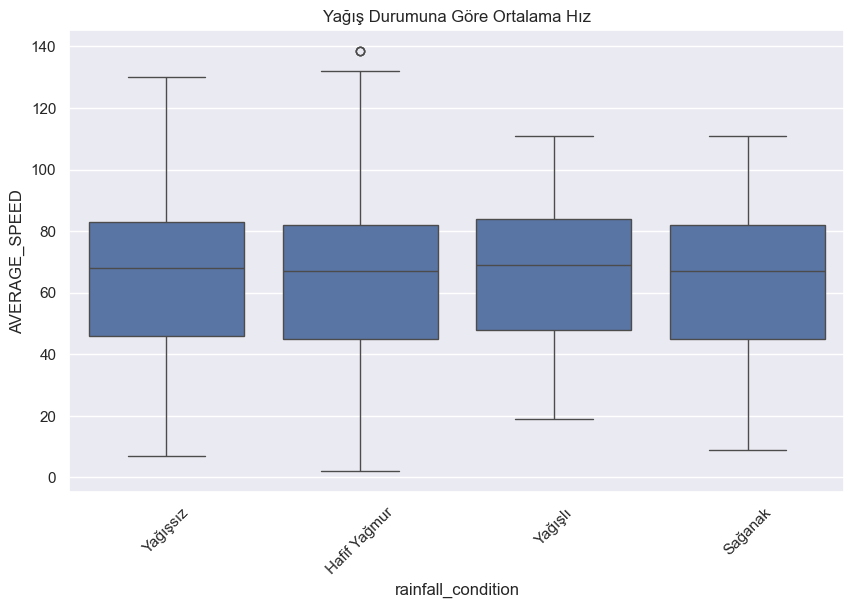

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(data=veri, x="rainfall_condition", y="AVERAGE_SPEED")
plt.title("Yağış Durumuna Göre Ortalama Hız")
plt.xticks(rotation=45)
plt.show()

Zaman Dilimi Bazında Araç Sayısı

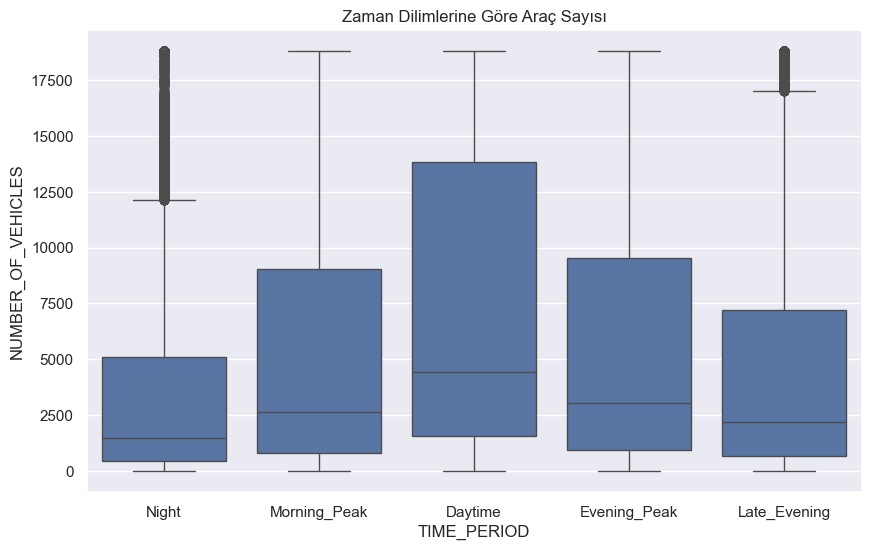

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(data=veri, x="TIME_PERIOD", y="NUMBER_OF_VEHICLES")
plt.title("Zaman Dilimlerine Göre Araç Sayısı")
plt.show()

Haftanın Gününe Göre Yoğunluk

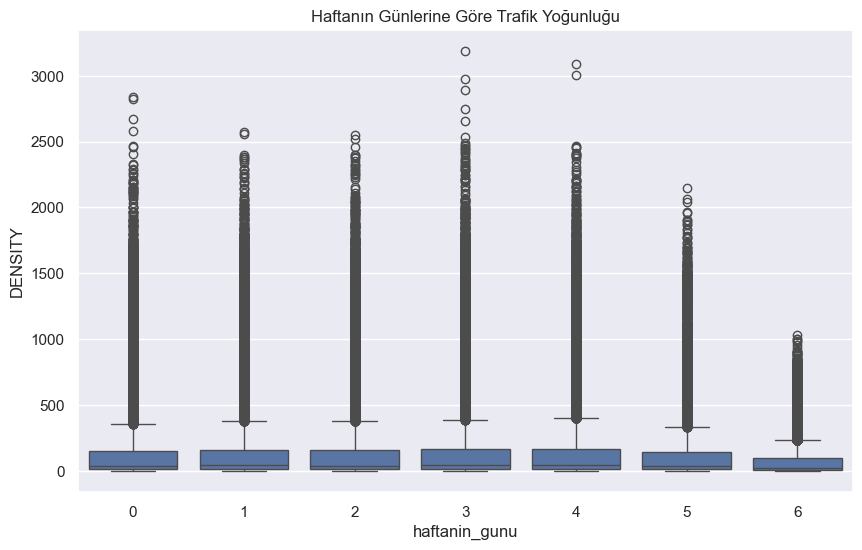

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(data=veri, x="haftanin_gunu", y="DENSITY")
plt.title("Haftanın Günlerine Göre Trafik Yoğunluğu")
plt.show()

Mekânsal Trafik Yoğunluğu

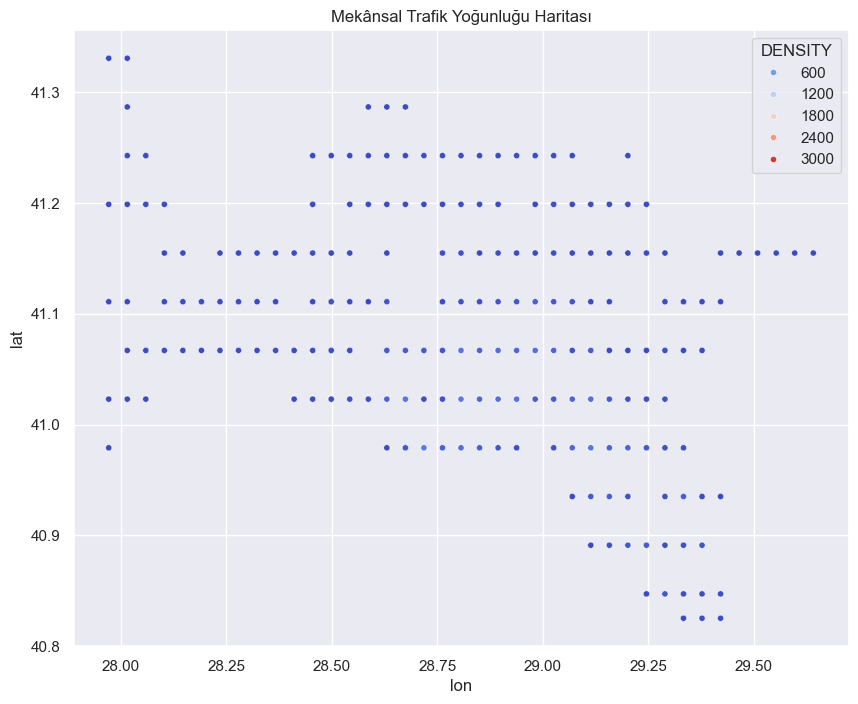

In [35]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=veri, x="lon", y="lat", hue="DENSITY",
                palette="coolwarm", s=20)
plt.title("Mekânsal Trafik Yoğunluğu Haritası")
plt.show()

In [36]:
veri.to_csv("proje.csv", index=False, encoding="utf-8-sig")